# Auto-Moderator: A Machine Learning Approach for Toxicity Classification in Online Communities

**Course:** COMP6885001 — Natural Language Processing  
**Group 11**

| Name | NIM |
|------|-----|
| Matthew Fitch Aurick | 2802389922 |
| Jayson Prasada Siswoyo | 2802389260 |
| Evan Chastya Pahan | 2802394185 |

---
### 4 Models Compared

|| Model | Type |
|---|-------|------|
| 1 | **Logistic Regression** | TF-IDF + OvR |
| 2 | **LinearSVC** | TF-IDF + OvR |
| 3 | **DistilBERT** | Transformer |
| 4 | **RoBERTa** | Transformer |

### Evaluation Metrics
- **Macro ROC-AUC** — primary metric (success criterion: > 0.90 for all models)
- **Macro F1, Precision, Recall** — per-label diagnostics
- **Hamming Loss** — fraction of incorrectly predicted labels


## Setup — Mount Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, os, time, joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, hamming_loss,
                             multilabel_confusion_matrix)
from sklearn.metrics import roc_curve

print('✅ Core libraries imported.')

✅ Core libraries imported.


### 1.0 — NLP Library Setup: NLTK & spaCy

| Library | Role in this project |
|---|---|
| `nltk` | Tokenization, stopword removal, token frequency analysis |
| `spacy` | POS tagging, linguistic feature extraction |
| `transformers` | DistilBERT & RoBERTa fine-tuning (Sections 3.3–3.4) |

In [ ]:
# Install and configure NLTK & spaCy
import subprocess
subprocess.run(['pip', 'install', '-q', 'nltk', 'spacy'], check=True)
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm', '-q'], check=True)

import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

nlp = spacy.load('en_core_web_sm')
STOP_WORDS = set(stopwords.words('english'))

print('✅ NLTK version   :', nltk.__version__)
print('✅ spaCy version  :', spacy.__version__)
print('✅ spaCy model    : en_core_web_sm')
print('✅ NLTK stopwords :', len(STOP_WORDS), 'words')


✅ NLTK version   : 3.9.1
✅ spaCy version  : 3.8.14
✅ spaCy model    : en_core_web_sm
✅ NLTK stopwords : 198 words


In [ ]:
BASE_DIR    = '/content/drive/MyDrive/Colab Notebooks/fipro nlp/output'
DIR_DATASET = os.path.join(BASE_DIR, 'Dataset')
DIR_MODEL1  = os.path.join(BASE_DIR, 'Model 1')   # Logistic Regression
DIR_MODEL2  = os.path.join(BASE_DIR, 'Model 2')   # LinearSVC
DIR_MODEL3  = os.path.join(BASE_DIR, 'Model 3')   # DistilBERT
DIR_MODEL4  = os.path.join(BASE_DIR, 'Model 4')   # RoBERTa
DIR_ANALYSIS= os.path.join(BASE_DIR, 'Analysis')

for d in [BASE_DIR, DIR_DATASET, DIR_MODEL1, DIR_MODEL2,
          DIR_MODEL3, DIR_MODEL4, DIR_ANALYSIS]:
    os.makedirs(d, exist_ok=True)

OUTPUT_DIR = BASE_DIR  # backward compatibility

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
PALETTE    = ['#1f4e79','#2e75b6','#4ba3c7','#70ad47','#ed7d31','#c00000']
COLORS     = PALETTE

print('✅ Output directories created.')
for name, path in [('Dataset', DIR_DATASET), ('Model 1', DIR_MODEL1),
                   ('Model 2', DIR_MODEL2),  ('Model 3', DIR_MODEL3),
                   ('Model 4', DIR_MODEL4),  ('Analysis', DIR_ANALYSIS)]:
    print(f'   📁 {name:<10} → {path}')

✅ Output directories created.
   📁 Dataset    → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Dataset
   📁 Model 1    → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 1
   📁 Model 2    → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 2
   📁 Model 3    → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 3
   📁 Model 4    → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 4
   📁 Analysis   → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Analysis


## Section 1 — Dataset & Exploratory Data Analysis

**Dataset:** Jigsaw Toxic Comment Classification (CC BY-SA 3.0)  
**Source:** [HuggingFace Datasets](https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge)


### 1.1 — Load Raw Data

In [ ]:
train_df       = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fipro nlp/train.csv')
test_df        = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fipro nlp/test.csv')
test_labels_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fipro nlp/test_labels.csv')

print('📁 File sizes')
print(f'  train.csv       : {len(train_df):,} rows × {train_df.shape[1]} cols')
print(f'  test.csv        : {len(test_df):,} rows × {test_df.shape[1]} cols')
print(f'  test_labels.csv : {len(test_labels_df):,} rows × {test_labels_df.shape[1]} cols')

valid    = test_labels_df[test_labels_df['toxic'] != -1]
excluded = test_labels_df[test_labels_df['toxic'] == -1]
print(f'\ntest_labels — valid  (label ≠ -1) : {len(valid):,}')
print(f'test_labels — excluded (label = -1) : {len(excluded):,}')
print(f'\nTrain columns : {list(train_df.columns)}')
print(f'\nFirst 3 rows of train_df:')
train_df.head(3)

📁 File sizes
  train.csv       : 159,571 rows × 8 cols
  test.csv        : 153,164 rows × 2 cols
  test_labels.csv : 153,164 rows × 7 cols

test_labels — valid  (label ≠ -1) : 63,978
test_labels — excluded (label = -1) : 89,186

Train columns : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

First 3 rows of train_df:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


### 1.2 — Label Inspection & Class Distribution

In [ ]:
# Verify label columns are binary
print('Label columns in train.csv:')
for col in LABEL_COLS:
    unique = sorted(train_df[col].unique().tolist())
    print(f'  {col:<16}: values = {unique}')

n = len(train_df)
non_toxic = (train_df[LABEL_COLS].sum(axis=1) == 0).sum()
multi     = (train_df[LABEL_COLS].sum(axis=1) >= 2).sum()

print(f'\nTotal training comments : {n:,}')
print(f'Non-toxic (all 0)       : {non_toxic:,} ({non_toxic/n*100:.1f}%)')
print(f'Multi-label (2+ labels) : {multi:,} ({multi/n*100:.1f}%)')
print()
print(f'  {"Label":<16} {"Positive":>10} {"Pct":>8}')
print('  ' + '-'*37)
for col in ['toxic','obscene','insult','severe_toxic','identity_hate','threat']:
    pos = train_df[col].sum()
    print(f'  {col:<16} {pos:>10,} {pos/n*100:>7.2f}%')

Label columns in train.csv:
  toxic           : values = [0, 1]
  severe_toxic    : values = [0, 1]
  obscene         : values = [0, 1]
  threat          : values = [0, 1]
  insult          : values = [0, 1]
  identity_hate   : values = [0, 1]

Total training comments : 159,571
Non-toxic (all 0)       : 143,346 (89.8%)
Multi-label (2+ labels) : 9,865 (6.2%)

  Label              Positive      Pct
  -------------------------------------
  toxic                15,294    9.58%
  obscene               8,449    5.29%
  insult                7,877    4.94%
  severe_toxic          1,595    1.00%
  identity_hate         1,405    0.88%
  threat                  478    0.30%


### 1.3 — EDA Visualizations

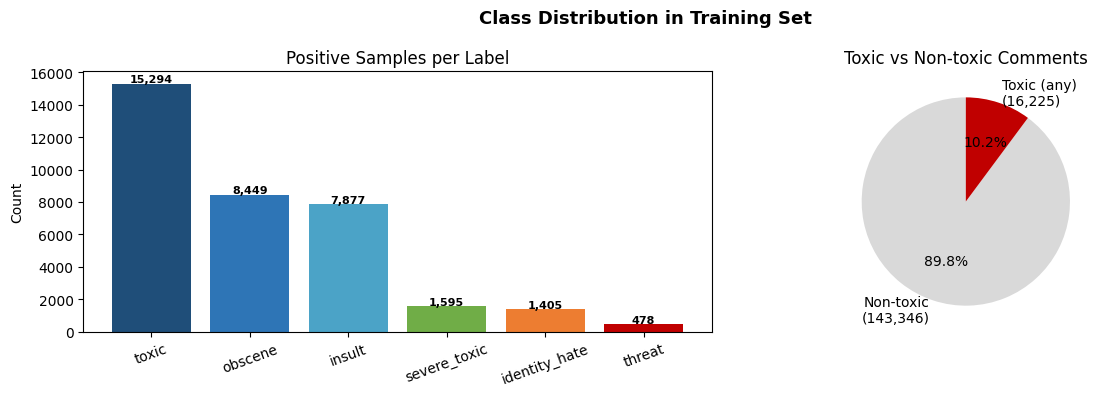

✅ Saved → Dataset/class_distribution.png


In [ ]:
# Plot 1: Class distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Class Distribution in Training Set', fontsize=13, fontweight='bold')

sorted_labels = ['toxic','obscene','insult','severe_toxic','identity_hate','threat']
counts = [train_df[c].sum() for c in sorted_labels]

bars = axes[0].bar(sorted_labels, counts, color=PALETTE)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Positive Samples per Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

n_toxic     = (train_df[LABEL_COLS].sum(axis=1) > 0).sum()
n_non_toxic = n - n_toxic
axes[1].pie([n_non_toxic, n_toxic],
            labels=[f'Non-toxic\n({n_non_toxic:,})', f'Toxic (any)\n({n_toxic:,})'],
            colors=['#d9d9d9', '#c00000'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Toxic vs Non-toxic Comments')

plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Dataset/class_distribution.png')

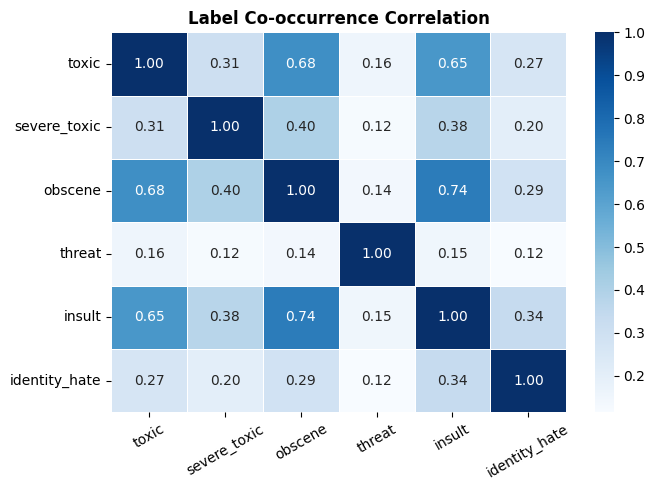

✅ Saved → Dataset/label_correlation.png


In [ ]:
# Plot 2: Label co-occurrence heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = train_df[LABEL_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax,
            xticklabels=LABEL_COLS, yticklabels=LABEL_COLS)
ax.set_title('Label Co-occurrence Correlation', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'label_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Dataset/label_correlation.png')

/tmp/ipykernel_699/3907296576.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(lengths_by_label, labels=label_names, patch_artist=True,


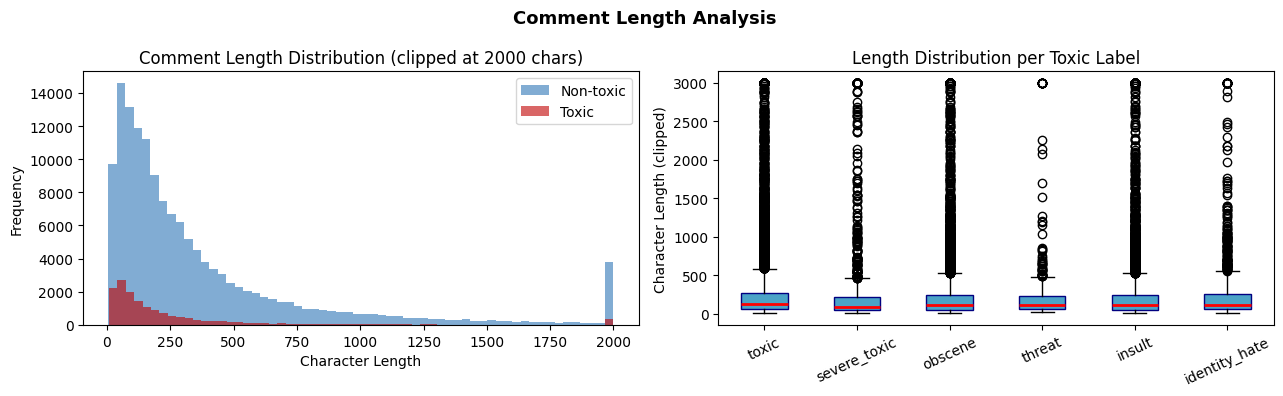

✅ Saved → Dataset/comment_length_dist.png


In [ ]:
# Plot 3: Comment length distribution
train_df['text_len'] = train_df['comment_text'].str.len()
toxic_mask = train_df['toxic'] == 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Comment Length Analysis', fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(train_df.loc[~toxic_mask, 'text_len'].clip(0, 2000),
             bins=60, alpha=0.6, label='Non-toxic', color='#2e75b6')
axes[0].hist(train_df.loc[toxic_mask, 'text_len'].clip(0, 2000),
             bins=60, alpha=0.6, label='Toxic', color='#c00000')
axes[0].set_title('Comment Length Distribution (clipped at 2000 chars)')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot per label
lengths_by_label = []
label_names = []
for col in LABEL_COLS:
    lengths_by_label.append(train_df[train_df[col] == 1]['text_len'].clip(0, 3000).values)
    label_names.append(col)
axes[1].boxplot(lengths_by_label, labels=label_names, patch_artist=True,
                boxprops=dict(facecolor='#4ba3c7', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Length Distribution per Toxic Label')
axes[1].set_ylabel('Character Length (clipped)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'comment_length_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Dataset/comment_length_dist.png')

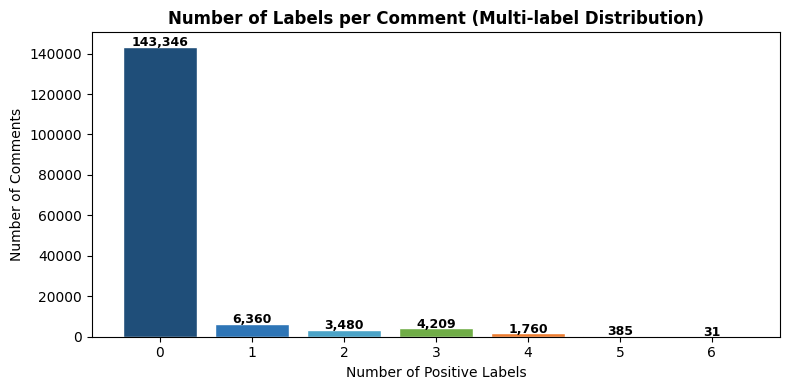

✅ Saved → Dataset/multilabel_dist.png


In [ ]:
# Plot 4: Multi-label count distribution
label_counts = train_df[LABEL_COLS].sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
vc = label_counts.value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='white')
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Number of Labels per Comment (Multi-label Distribution)', fontweight='bold')
ax.set_xlabel('Number of Positive Labels')
ax.set_ylabel('Number of Comments')
ax.set_xticks(vc.index)
plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'multilabel_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → Dataset/multilabel_dist.png')

### 1.3b — Linguistic EDA with NLTK & spaCy

Using **NLTK** for token frequency analysis (top-20 words in toxic vs. non-toxic comments, after stopword removal) and **spaCy** for POS tag distribution comparison.

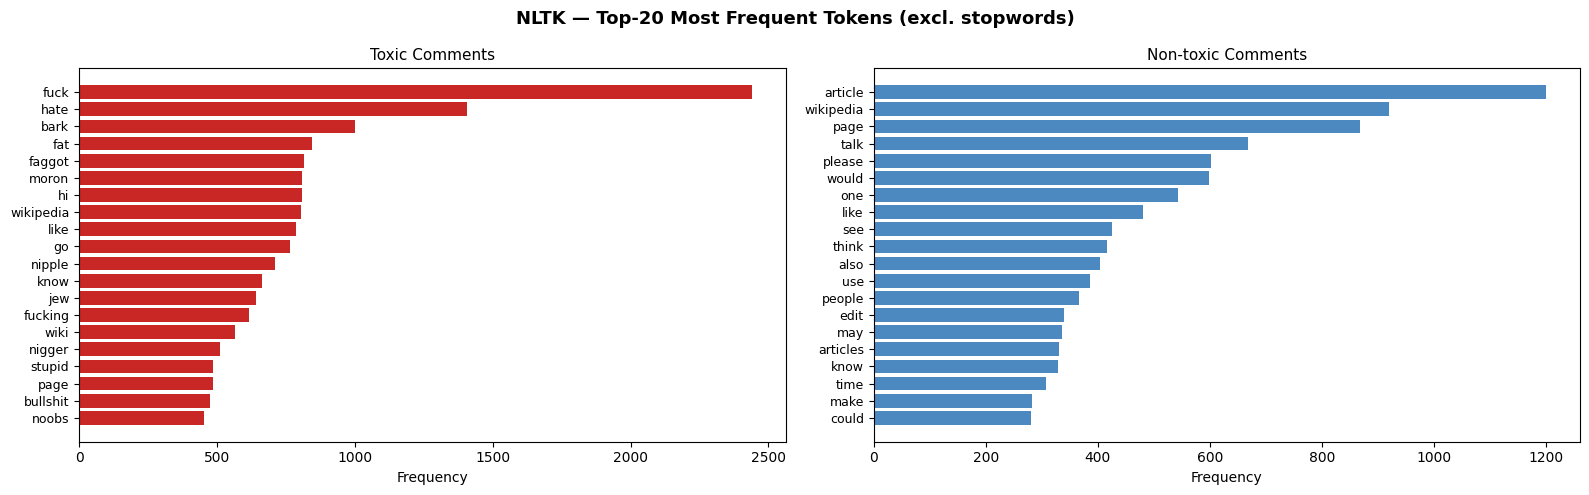

✅ NLTK token frequency analysis done.
   Toxic vocab (sampled)    : 11,970 unique tokens
   Non-toxic vocab (sampled): 16,069 unique tokens


In [ ]:
# ── NLTK: Top token frequency (toxic vs non-toxic) ──────────────────────────
import random
random.seed(42)

toxic_texts    = train_df[train_df['toxic'] == 1]['comment_text'].dropna().tolist()
nontoxic_texts = train_df[train_df['toxic'] == 0]['comment_text'].dropna().tolist()
toxic_sample    = random.sample(toxic_texts,    min(3000, len(toxic_texts)))
nontoxic_sample = random.sample(nontoxic_texts, min(3000, len(nontoxic_texts)))

def get_tokens(texts):
    tokens = []
    for t in texts:
        toks = word_tokenize(t.lower())
        toks = [w for w in toks if w.isalpha() and w not in STOP_WORDS]
        tokens.extend(toks)
    return tokens

toxic_tokens    = get_tokens(toxic_sample)
nontoxic_tokens = get_tokens(nontoxic_sample)
toxic_freq      = FreqDist(toxic_tokens)
nontoxic_freq   = FreqDist(nontoxic_tokens)

top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('NLTK — Top-20 Most Frequent Tokens (excl. stopwords)', fontsize=13, fontweight='bold')

for ax, freq, title, color in [
    (axes[0], toxic_freq,    'Toxic Comments',     '#c00000'),
    (axes[1], nontoxic_freq, 'Non-toxic Comments', '#2e75b6'),
]:
    words, counts = zip(*freq.most_common(top_n))
    ax.barh(range(top_n), list(counts)[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(list(words)[::-1], fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'nltk_token_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ NLTK token frequency analysis done.')
print(f'   Toxic vocab (sampled)    : {len(toxic_freq):,} unique tokens')
print(f'   Non-toxic vocab (sampled): {len(nontoxic_freq):,} unique tokens')

Running spaCy POS tagging (500 samples each)...


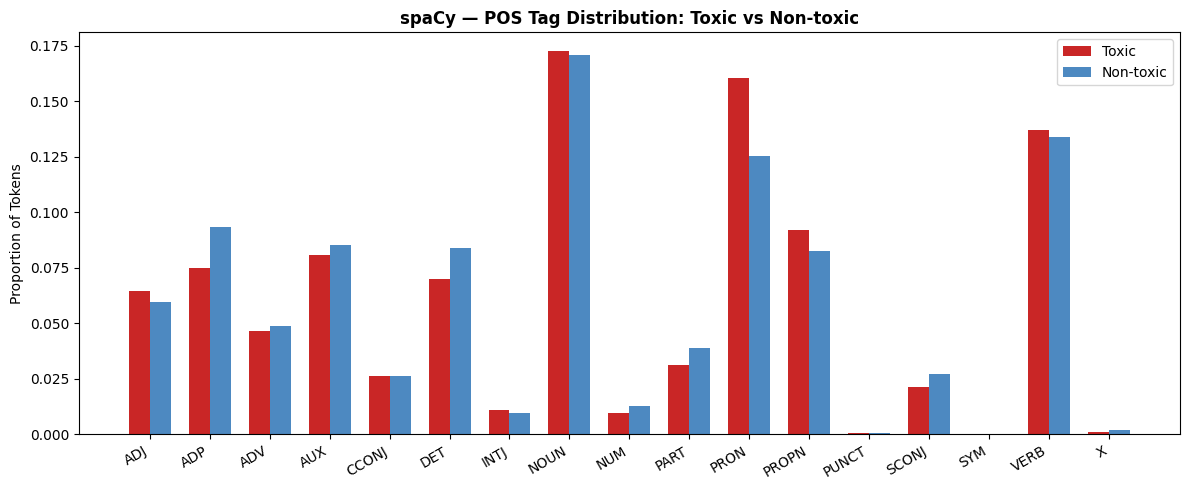

✅ spaCy POS distribution done.
   POS tags found: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


In [ ]:
# ── spaCy: POS Tag Distribution (toxic vs non-toxic) ────────────────────────
spacy_n = 500
toxic_spacy    = random.sample(toxic_texts,    min(spacy_n, len(toxic_texts)))
nontoxic_spacy = random.sample(nontoxic_texts, min(spacy_n, len(nontoxic_texts)))

def get_pos_dist(texts):
    pos_counts = {}
    for t in texts:
        doc = nlp(t[:200])  # clip for speed
        for token in doc:
            if not token.is_punct and not token.is_space:
                pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1
    total = sum(pos_counts.values())
    return {k: v / total for k, v in sorted(pos_counts.items(), key=lambda x: -x[1])}

print('Running spaCy POS tagging (500 samples each)...')
pos_toxic    = get_pos_dist(toxic_spacy)
pos_nontoxic = get_pos_dist(nontoxic_spacy)

all_pos       = sorted(set(pos_toxic) | set(pos_nontoxic))
toxic_vals    = [pos_toxic.get(p, 0)    for p in all_pos]
nontoxic_vals = [pos_nontoxic.get(p, 0) for p in all_pos]

x = np.arange(len(all_pos))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, toxic_vals,    w, label='Toxic',     color='#c00000', alpha=0.85)
ax.bar(x + w/2, nontoxic_vals, w, label='Non-toxic', color='#2e75b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_pos, rotation=30, ha='right')
ax.set_ylabel('Proportion of Tokens')
ax.set_title('spaCy — POS Tag Distribution: Toxic vs Non-toxic', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_DATASET, 'spacy_pos_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ spaCy POS distribution done.')
print('   POS tags found:', all_pos)


### 1.4 — Missing Value Check & Test Set Filtering

In [ ]:
# Missing value analysis
print('🔍 Missing Values in train_df:')
mv = train_df.isnull().sum()
print(mv[mv > 0] if mv.any() else '   None found ✅')

print('\n🔍 Missing Values in test_df:')
mv2 = test_df.isnull().sum()
print(mv2[mv2 > 0] if mv2.any() else '   None found ✅')

# Merge test + labels, filter out -1 rows
test_full  = test_df.merge(test_labels_df, on='id')
test_valid = test_full[test_full['toxic'] != -1].reset_index(drop=True)

print(f'\n✅ Train samples     : {len(train_df):,}')
print(f'✅ Test samples      : {len(test_df):,}')
print(f'✅ Valid test labels : {len(test_valid):,}  (excluded -1 entries)')

🔍 Missing Values in train_df:
   None found ✅

🔍 Missing Values in test_df:
   None found ✅

✅ Train samples     : 159,571
✅ Test samples      : 153,164
✅ Valid test labels : 63,978  (excluded -1 entries)


### 1.5 — Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
    """Remove HTML tags, URLs, special characters; normalize whitespace; lowercase."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)            # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # URLs
    text = re.sub(r'[^a-zA-Z0-9\s!?.,]', ' ', text) # special chars
    text = re.sub(r'\s+', ' ', text).strip()         # whitespace
    return text.lower()

train_df['clean_text']  = train_df['comment_text'].apply(clean_text)
test_valid['clean_text'] = test_valid['comment_text'].apply(clean_text)

print('✅ Text cleaned.')
print('\nSample before:', repr(train_df['comment_text'].iloc[10][:120]))
print('Sample after :', repr(train_df['clean_text'].iloc[10][:120]))

✅ Text cleaned.

Sample before: '"\nFair use rationale for Image:Wonju.jpg\n\nThanks for uploading Image:Wonju.jpg. I notice the image page specifies that t'
Sample after : 'fair use rationale for image wonju.jpg thanks for uploading image wonju.jpg. i notice the image page specifies that the '


### 1.6 — Train / Validation / Test Split

In [ ]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train_df['clean_text'].values,
    train_df[LABEL_COLS].values,
    test_size=0.15,
    random_state=42,
    stratify=train_df['toxic'].values
)

X_test_raw = test_valid['clean_text'].values
y_test     = test_valid[LABEL_COLS].values

print('📊 Data split summary:')
print(f'  Train  : {len(X_train_raw):,} samples')
print(f'  Val    : {len(X_val_raw):,} samples')
print(f'  Test   : {len(X_test_raw):,} samples')
print()
print('Label distribution in splits:')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_s = len(y_split)
    toxic_pct = y_split[:, 0].mean() * 100
    print(f'  {split_name:<6}: {n_s:>7,} samples | toxic rate = {toxic_pct:.1f}%')

📊 Data split summary:
  Train  : 135,635 samples
  Val    : 23,936 samples
  Test   : 63,978 samples

Label distribution in splits:
  Train : 135,635 samples | toxic rate = 9.6%
  Val   :  23,936 samples | toxic rate = 9.6%
  Test  :  63,978 samples | toxic rate = 9.5%


## Section 2 — Data Preprocessing & Feature Extraction


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

print('⏳ Fitting TF-IDF vectorizer (max_features=100K, unigrams+bigrams)…')
tfidf = TfidfVectorizer(
    max_features=100_000,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3
)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f'✅ TF-IDF matrix shape : {X_train_tfidf.shape}')
print(f'   Vocabulary size     : {len(tfidf.vocabulary_):,}')
print(f'   Val matrix shape    : {X_val_tfidf.shape}')
print(f'   Test matrix shape   : {X_test_tfidf.shape}')

⏳ Fitting TF-IDF vectorizer (max_features=100K, unigrams+bigrams)…
✅ TF-IDF matrix shape : (135635, 100000)
   Vocabulary size     : 100,000
   Val matrix shape    : (23936, 100000)
   Test matrix shape   : (63978, 100000)


## Shared Evaluation & Visualization Utilities


In [ ]:
def evaluate_model(model_name, y_true, y_pred_proba, y_pred_binary=None):
    """
    Full evaluation suite:
      - Macro ROC-AUC + per-label ROC-AUC
      - Macro F1, Precision, Recall
      - Per-label F1, Precision, Recall
      - Hamming Loss
    Returns a dict of results.
    """
    if y_pred_binary is None:
        y_pred_binary = (y_pred_proba >= 0.5).astype(int)

    results = {'model': model_name}
    roc_per = roc_auc_score(y_true, y_pred_proba, average=None)
    results['roc_auc_macro']     = roc_auc_score(y_true, y_pred_proba, average='macro')
    results['roc_auc_per_label'] = dict(zip(LABEL_COLS, roc_per))
    results['f1_macro']          = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
    results['precision_macro']   = precision_score(y_true, y_pred_binary, average='macro', zero_division=0)
    results['recall_macro']      = recall_score(y_true, y_pred_binary, average='macro', zero_division=0)
    results['f1_per_label']        = dict(zip(LABEL_COLS, f1_score(y_true, y_pred_binary, average=None, zero_division=0)))
    results['precision_per_label'] = dict(zip(LABEL_COLS, precision_score(y_true, y_pred_binary, average=None, zero_division=0)))
    results['recall_per_label']    = dict(zip(LABEL_COLS, recall_score(y_true, y_pred_binary, average=None, zero_division=0)))
    results['hamming_loss']      = hamming_loss(y_true, y_pred_binary)
    return results


def print_results(results):
    print(f"\n{'='*55}")
    print(f"  📊 Results: {results['model']}")
    print(f"{'='*55}")
    print(f"  Macro ROC-AUC  : {results['roc_auc_macro']:.4f}  {'✅' if results['roc_auc_macro'] >= 0.9 else '❌ (target: >0.90)'}")
    print(f"  Macro F1       : {results['f1_macro']:.4f}")
    print(f"  Macro Precision: {results['precision_macro']:.4f}")
    print(f"  Macro Recall   : {results['recall_macro']:.4f}")
    print(f"  Hamming Loss   : {results['hamming_loss']:.4f}")
    print(f"\n  Per-label ROC-AUC:")
    for lbl, v in results['roc_auc_per_label'].items():
        print(f"    {lbl:<15}: {v:.4f}")
    print(f"\n  Per-label F1 / Precision / Recall:")
    print(f"    {'Label':<15} {'F1':>6} {'Prec':>6} {'Rec':>6}")
    print(f"    {'-'*38}")
    for lbl in LABEL_COLS:
        f1 = results['f1_per_label'][lbl]
        pr = results['precision_per_label'][lbl]
        rc = results['recall_per_label'][lbl]
        print(f"    {lbl:<15} {f1:>6.4f} {pr:>6.4f} {rc:>6.4f}")


all_results = []
print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


In [ ]:
def plot_roc_curves(model_name, y_true, y_pred_proba, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f'ROC Curves — {model_name}', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    for i, lbl in enumerate(LABEL_COLS):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        auc = roc_auc_score(y_true[:, i], y_pred_proba[:, i])
        axes[i].plot(fpr, tpr, color=COLORS[i], lw=2, label=f'AUC = {auc:.4f}')
        axes[i].plot([0,1],[0,1],'k--', lw=1)
        axes[i].set_title(lbl)
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].legend(loc='lower right')
        axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1.02])
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrices(model_name, y_true, y_pred_binary, save_path=None):
    mcm = multilabel_confusion_matrix(y_true, y_pred_binary)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f'Confusion Matrices — {model_name}', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    for i, (lbl, cm) in enumerate(zip(LABEL_COLS, mcm)):
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    cmap='Blues', linewidths=0.5,
                    xticklabels=['Pred 0','Pred 1'],
                    yticklabels=['True 0','True 1'])
        axes[i].set_title(lbl)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_per_label_metrics(results, save_path=None):
    model_name = results['model']
    f1s  = list(results['f1_per_label'].values())
    prcs = list(results['precision_per_label'].values())
    rcs  = list(results['recall_per_label'].values())
    aucs = list(results['roc_auc_per_label'].values())

    x = np.arange(len(LABEL_COLS)); w = 0.2
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - 1.5*w, f1s,  w, label='F1',       color='#1f4e79')
    ax.bar(x - 0.5*w, prcs, w, label='Precision', color='#2e75b6')
    ax.bar(x + 0.5*w, rcs,  w, label='Recall',    color='#4ba3c7')
    ax.bar(x + 1.5*w, aucs, w, label='ROC-AUC',   color='#70ad47')
    ax.set_xticks(x); ax.set_xticklabels(LABEL_COLS, rotation=20)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
    ax.set_title(f'Per-Label Metrics — {model_name}')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('✅ Visualization utilities ready.')

✅ Visualization utilities ready.


## Section 3 — Model Training & Evaluation


### 3.1 — Model 1: Logistic Regression (TF-IDF + OvR)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

print('⏳ Training Model 1: Logistic Regression…')
t0 = time.time()

lr_model = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                       class_weight='balanced', random_state=42, n_jobs=-1),
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)
print(f'✅ Trained in {time.time()-t0:.1f}s')

lr_val_proba  = lr_model.predict_proba(X_val_tfidf)
lr_test_proba = lr_model.predict_proba(X_test_tfidf)
lr_test_bin   = (lr_test_proba >= 0.5).astype(int)

lr_results = evaluate_model('Logistic Regression', y_test, lr_test_proba, lr_test_bin)
all_results.append(lr_results)
print_results(lr_results)

⏳ Training Model 1: Logistic Regression…
✅ Trained in 15.2s

  📊 Results: Logistic Regression
  Macro ROC-AUC  : 0.9746  ✅
  Macro F1       : 0.4725
  Macro Precision: 0.3415
  Macro Recall   : 0.8445
  Hamming Loss   : 0.0502

  Per-label ROC-AUC:
    toxic          : 0.9557
    severe_toxic   : 0.9830
    obscene        : 0.9722
    threat         : 0.9918
    insult         : 0.9671
    identity_hate  : 0.9779

  Per-label F1 / Precision / Recall:
    Label               F1   Prec    Rec
    --------------------------------------
    toxic           0.6007 0.4569 0.8768
    severe_toxic    0.2590 0.1527 0.8529
    obscene         0.6319 0.5014 0.8540
    threat          0.3863 0.2518 0.8294
    insult          0.5761 0.4367 0.8462
    identity_hate   0.3809 0.2492 0.8076


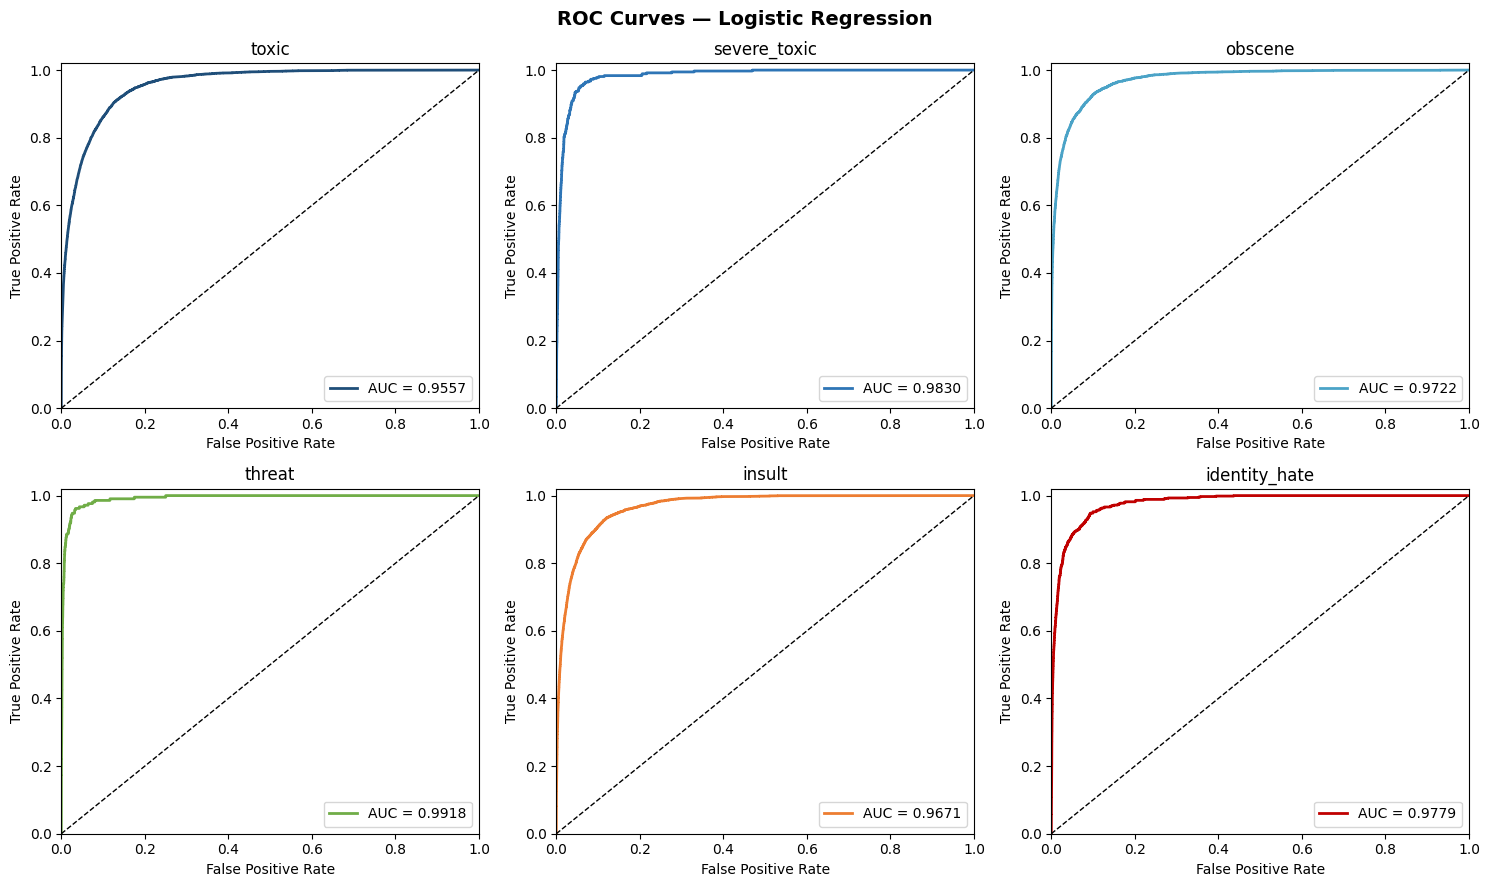

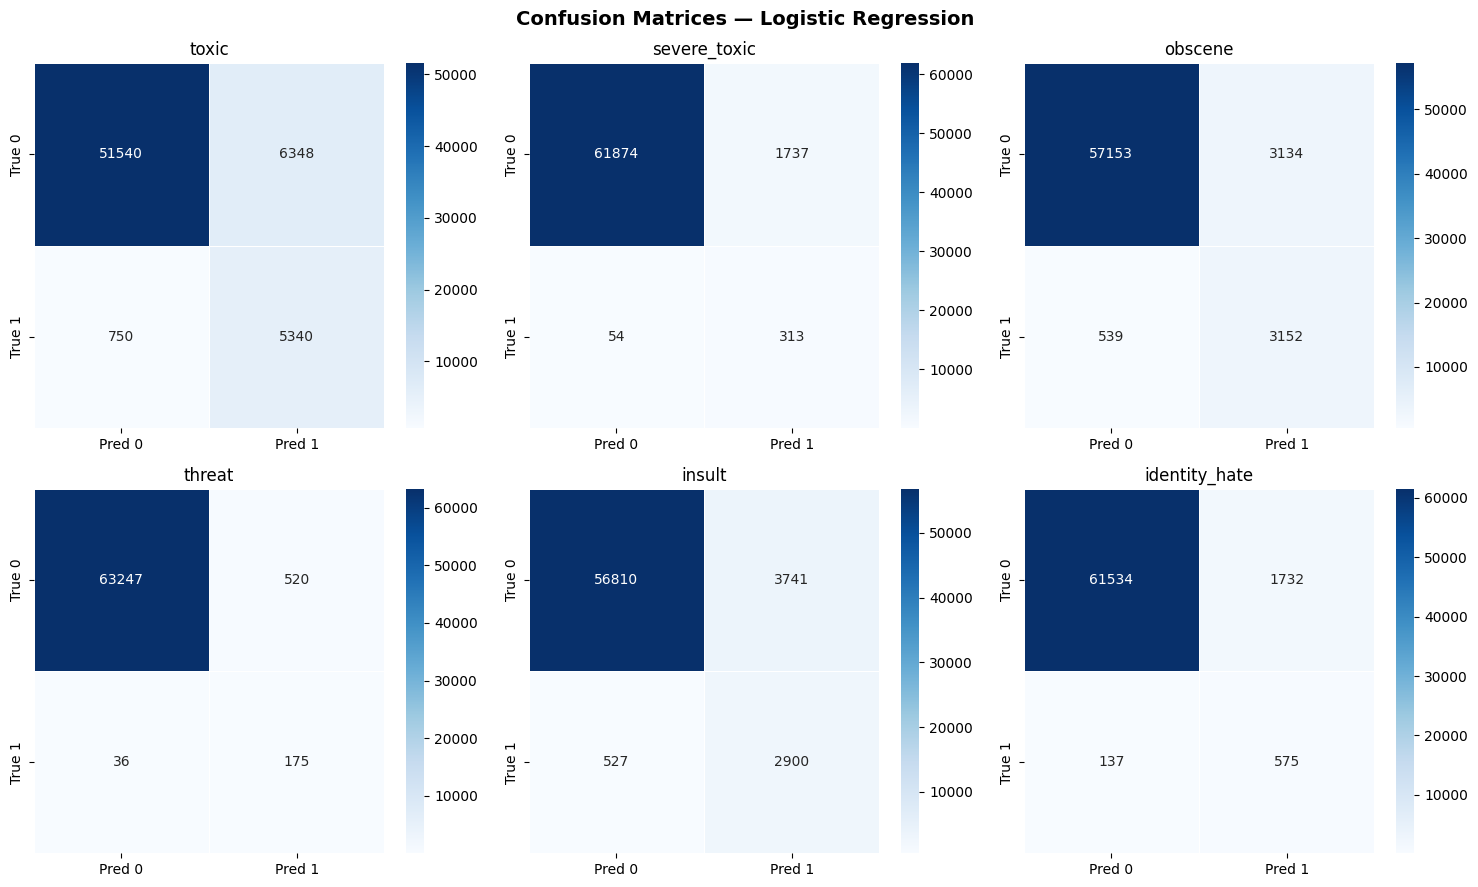

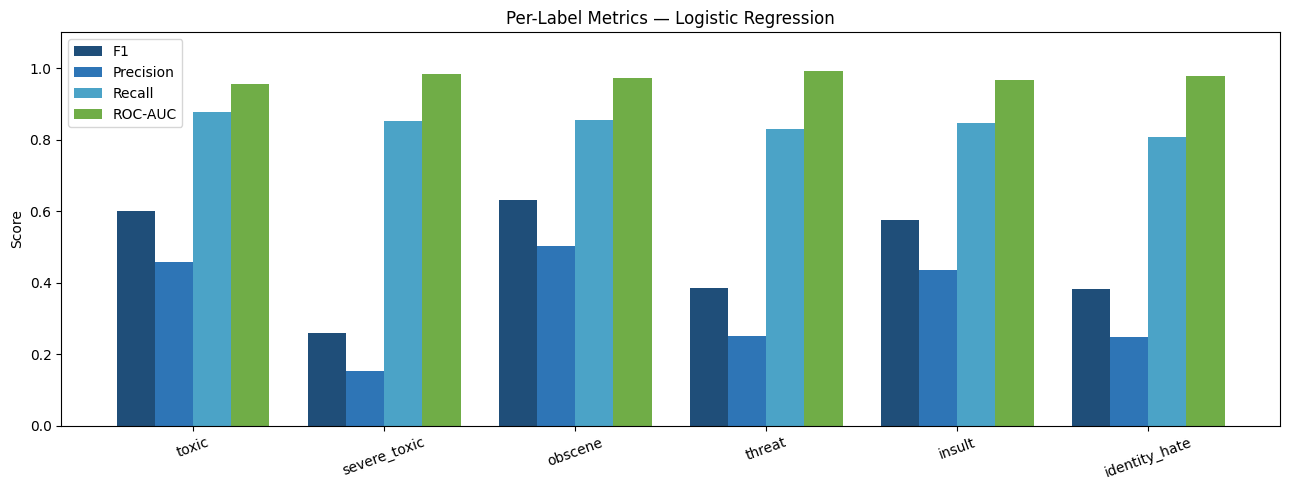

✅ Model 1 — all artifacts saved to Model 1/


In [ ]:
# Visualize Model 1
plot_roc_curves('Logistic Regression', y_test, lr_test_proba,
                save_path=os.path.join(DIR_MODEL1, 'lr_roc_curves.png'))
plot_confusion_matrices('Logistic Regression', y_test, lr_test_bin,
                        save_path=os.path.join(DIR_MODEL1, 'lr_confusion.png'))
plot_per_label_metrics(lr_results,
                       save_path=os.path.join(DIR_MODEL1, 'lr_per_label.png'))

# Save artifacts
joblib.dump(lr_model, os.path.join(DIR_MODEL1, 'lr_model.pkl'))
joblib.dump(tfidf,    os.path.join(DIR_MODEL1, 'tfidf_vectorizer.pkl'))
pd.DataFrame([lr_results]).to_csv(os.path.join(DIR_MODEL1, 'lr_results.csv'), index=False)
print('✅ Model 1 — all artifacts saved to Model 1/')

### 3.2 — Model 2: LinearSVC (TF-IDF + OvR)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print('⏳ Training Model 2: LinearSVC…')
t0 = time.time()

svc_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(C=0.1, max_iter=2000, class_weight='balanced', random_state=42),
        cv=3
    ),
    n_jobs=-1
)
svc_model.fit(X_train_tfidf, y_train)
print(f'✅ Trained in {time.time()-t0:.1f}s')

svc_test_proba = svc_model.predict_proba(X_test_tfidf)
svc_test_bin   = (svc_test_proba >= 0.5).astype(int)

svc_results = evaluate_model('LinearSVC', y_test, svc_test_proba, svc_test_bin)
all_results.append(svc_results)
print_results(svc_results)

⏳ Training Model 2: LinearSVC…
✅ Trained in 30.6s

  📊 Results: LinearSVC
  Macro ROC-AUC  : 0.9747  ✅
  Macro F1       : 0.5401
  Macro Precision: 0.5848
  Macro Recall   : 0.5142
  Hamming Loss   : 0.0267

  Per-label ROC-AUC:
    toxic          : 0.9557
    severe_toxic   : 0.9832
    obscene        : 0.9726
    threat         : 0.9912
    insult         : 0.9677
    identity_hate  : 0.9778

  Per-label F1 / Precision / Recall:
    Label               F1   Prec    Rec
    --------------------------------------
    toxic           0.6625 0.6143 0.7189
    severe_toxic    0.3525 0.3534 0.3515
    obscene         0.6989 0.7153 0.6833
    threat          0.4484 0.4785 0.4218
    insult          0.6230 0.7091 0.5556
    identity_hate   0.4553 0.6380 0.3539


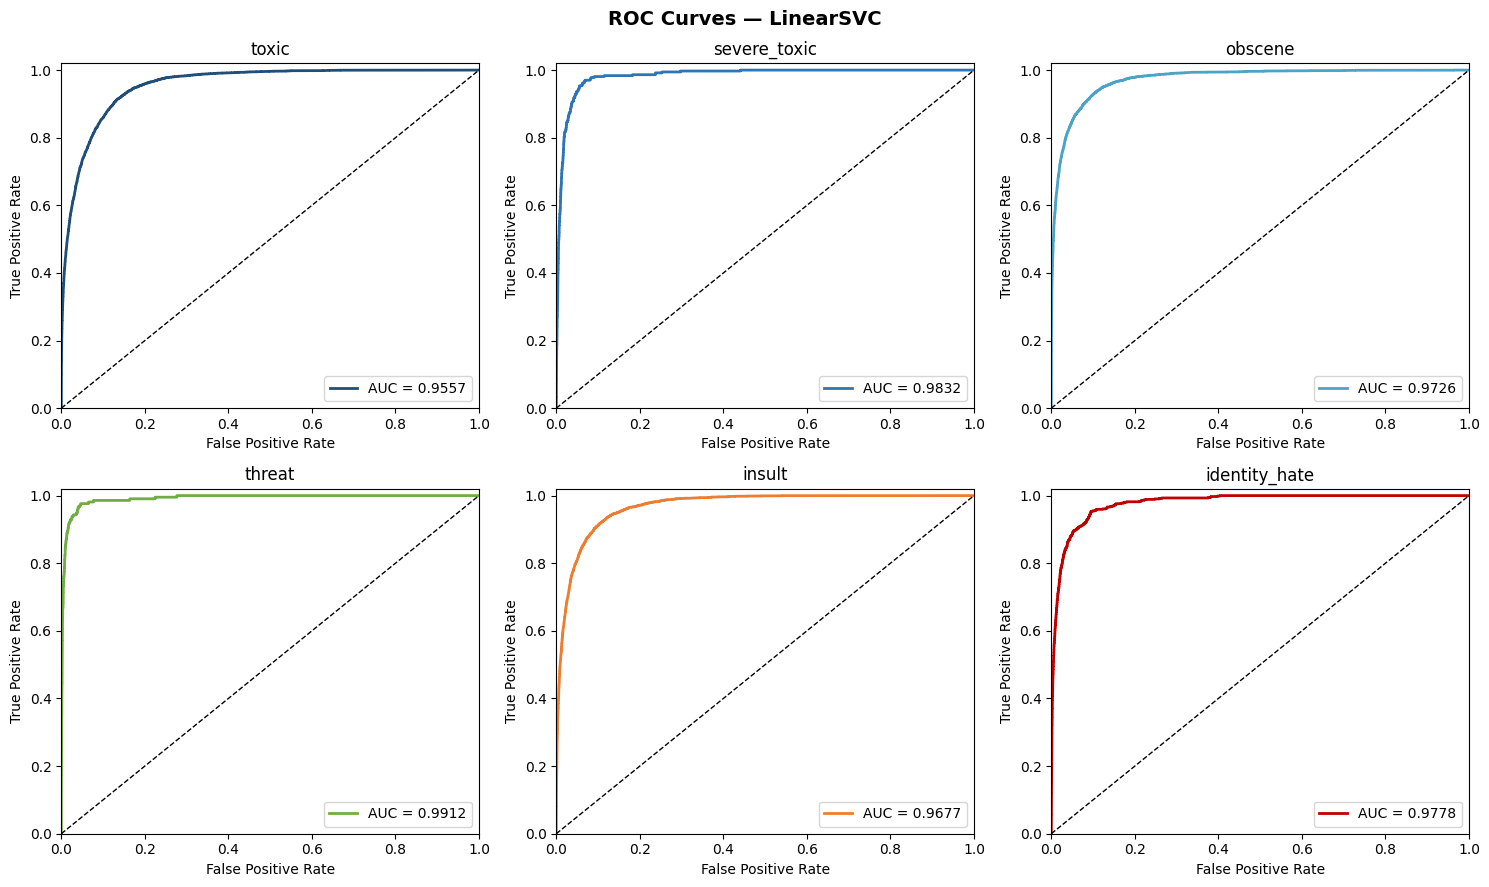

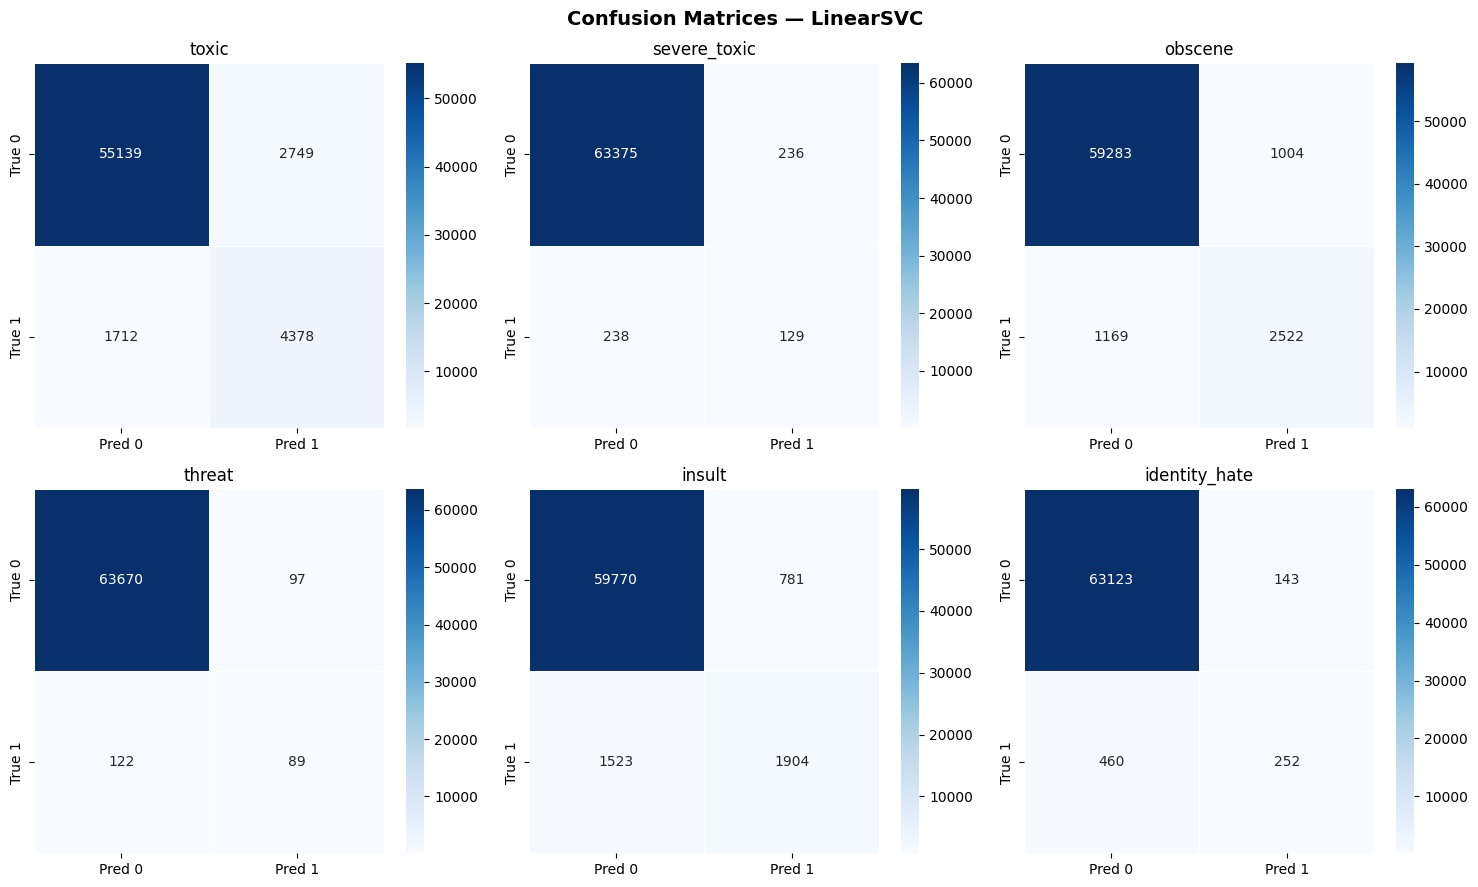

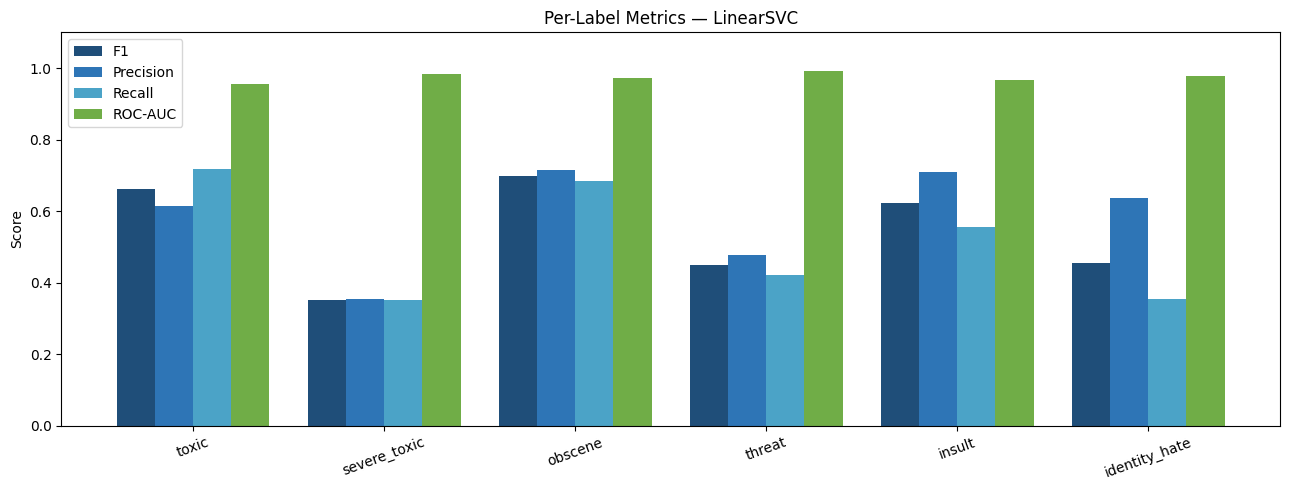

✅ Model 2 — all artifacts saved to Model 2/


In [ ]:
# Visualize Model 2
plot_roc_curves('LinearSVC', y_test, svc_test_proba,
                save_path=os.path.join(DIR_MODEL2, 'svc_roc_curves.png'))
plot_confusion_matrices('LinearSVC', y_test, svc_test_bin,
                        save_path=os.path.join(DIR_MODEL2, 'svc_confusion.png'))
plot_per_label_metrics(svc_results,
                       save_path=os.path.join(DIR_MODEL2, 'svc_per_label.png'))

joblib.dump(svc_model, os.path.join(DIR_MODEL2, 'svc_model.pkl'))
joblib.dump(tfidf,     os.path.join(DIR_MODEL2, 'tfidf_vectorizer.pkl'))
pd.DataFrame([svc_results]).to_csv(os.path.join(DIR_MODEL2, 'svc_results.csv'), index=False)
print('✅ Model 2 — all artifacts saved to Model 2/')

### 3.3 — Model 3: DistilBERT (Fine-tuned Transformer)

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
NUM_LABELS = len(LABEL_COLS)

print(f'🖥️  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [ ]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float)
        }


class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        hidden          = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, num_labels))

    def forward(self, input_ids, attention_mask):
        out     = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_out = out.last_hidden_state[:, 0, :]
        return self.classifier(cls_out)  # raw logits

print('✅ ToxicDataset & TransformerClassifier defined.')

✅ ToxicDataset & TransformerClassifier defined.


### Class Imbalance Handling Strategy

The Jigsaw dataset is severely imbalanced:

| Label | Positive % | Neg:Pos Ratio |
|---|---|---|
| toxic | 9.58% | ~9:1 |
| severe_toxic | 1.00% | ~99:1 |
| obscene | 5.29% | ~18:1 |
| threat | 0.30% | ~332:1 |
| insult | 4.94% | ~19:1 |
| identity_hate | 0.88% | ~112:1 |

**Strategy applied across all models:**

1. **Sklearn (LR & LinearSVC):** `class_weight='balanced'` — scikit-learn automatically sets each class weight to `n_samples / (n_classes * n_samples_per_class)`, penalizing errors on minority classes more heavily.

2. **Transformers (DistilBERT & RoBERTa):** `BCEWithLogitsLoss(pos_weight=...)` — per-label `pos_weight[i] = n_negative[i] / n_positive[i]` computed from the training set. This is the standard PyTorch approach for imbalanced binary classification (PyTorch Documentation, `torch.nn.BCEWithLogitsLoss`).

3. **Stratified split:** `train_test_split(..., stratify=train_df['toxic'])` ensures the toxic label ratio is preserved across train/val/test.

4. **Decision threshold:** Fixed at **0.5** (standard default) for all labels and all models. No arbitrary per-label threshold tuning is applied in the notebook.


In [ ]:
def train_transformer(model_name, display_name, X_train, y_train, X_val, y_val,
                      X_test, y_test, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    """Full training + evaluation pipeline for a transformer model."""
    print(f'\n{"─"*55}')
    print(f'🚀 Training: {display_name}  ({model_name})')
    print(f'{"─"*55}')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds  = ToxicDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds    = ToxicDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds   = ToxicDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_dl  = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_dl    = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_dl   = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # ── Class-Imbalance Handling: pos_weight per label ──────────────────────
    # For each label i: pos_weight[i] = (# negative samples) / (# positive samples)
    # This is the standard approach from PyTorch docs for imbalanced binary classification.
    # Reference: PyTorch BCEWithLogitsLoss — pos_weight parameter.
    y_train_tensor = torch.tensor(y_train, dtype=torch.float)
    n_pos  = y_train_tensor.sum(dim=0).clamp(min=1)          # avoid div-by-zero
    n_neg  = len(y_train) - n_pos
    pos_w  = (n_neg / n_pos).to(DEVICE)
    print(f'  pos_weight per label: { {l: round(v, 1) for l, v in zip(LABEL_COLS, pos_w.cpu().tolist())} }')

    model     = TransformerClassifier(model_name, NUM_LABELS).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_dl) * epochs
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_roc_auc': []}

    for epoch in range(1, epochs + 1):
        model.train(); total_loss = 0
        for batch in train_dl:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            loss  = criterion(model(ids, mask), lbls)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_dl)

        model.eval(); val_loss = 0; vp, vt = [], []
        with torch.no_grad():
            for batch in val_dl:
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                lbls = batch['labels'].to(DEVICE)
                logits = model(ids, mask)
                val_loss += criterion(logits, lbls).item()
                vp.append(torch.sigmoid(logits).cpu().numpy())
                vt.append(lbls.cpu().numpy())
        avg_val  = val_loss / len(val_dl)
        val_roc  = roc_auc_score(np.vstack(vt), np.vstack(vp), average='macro')
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_roc_auc'].append(val_roc)
        print(f'  Epoch {epoch}/{epochs}  |  Train Loss: {avg_train:.4f}  |  Val Loss: {avg_val:.4f}  |  Val ROC-AUC: {val_roc:.4f}')

    model.eval(); tp, tt = [], []
    with torch.no_grad():
        for batch in test_dl:
            logits = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            tp.append(torch.sigmoid(logits).cpu().numpy())
            tt.append(batch['labels'].numpy())
    test_proba = np.vstack(tp); test_true = np.vstack(tt)
    # Decision threshold = 0.5 (standard default; no arbitrary per-label tuning)
    test_bin   = (test_proba >= 0.5).astype(int)
    results    = evaluate_model(display_name, test_true, test_proba, test_bin)

    _dir_map = {'DistilBERT': DIR_MODEL3, 'RoBERTa': DIR_MODEL4}
    model_dir = _dir_map.get(display_name, OUTPUT_DIR)
    safe_name = display_name.replace(' ', '_').lower()
    torch.save({'model_state_dict': model.state_dict(), 'model_name': model_name,
                'display_name': display_name, 'history': history, 'results': results},
               os.path.join(model_dir, f'{safe_name}_model.pt'))
    print(f'\n  ✅ Model saved → {model_dir}/{safe_name}_model.pt')
    return results, history, test_proba, test_true, test_bin


def plot_training_history(history, display_name, save_path=None):
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Training History — {display_name}', fontsize=13, fontweight='bold')
    axes[0].plot(ep, history['train_loss'], 'o-', label='Train Loss', color='#1f4e79')
    axes[0].plot(ep, history['val_loss'],   's-', label='Val Loss',   color='#ed7d31')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
    axes[0].legend(); axes[0].set_xticks(list(ep))
    axes[1].plot(ep, history['val_roc_auc'], 'D-', label='Val ROC-AUC (macro)', color='#70ad47')
    axes[1].set_title('Validation ROC-AUC'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC'); axes[1].legend()
    axes[1].set_xticks(list(ep)); axes[1].set_ylim(0.5, 1.0)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Transformer training utilities ready.')

✅ Transformer training utilities ready.


In [ ]:
# Train DistilBERT
distilbert_results, distilbert_history, db_proba, db_true, db_bin = train_transformer(
    model_name='distilbert-base-uncased', display_name='DistilBERT',
    X_train=X_train_raw, y_train=y_train,
    X_val=X_val_raw,     y_val=y_val,
    X_test=X_test_raw,   y_test=y_test,
)
all_results.append(distilbert_results)
print_results(distilbert_results)


───────────────────────────────────────────────────────
🚀 Training: DistilBERT  (distilbert-base-uncased)
───────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

  pos_weight per label: {'toxic': 9.4, 'severe_toxic': 98.3, 'obscene': 17.9, 'threat': 336.4, 'insult': 19.3, 'identity_hate': 113.0}


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/3  |  Train Loss: 0.5150  |  Val Loss: 0.4074  |  Val ROC-AUC: 0.9887
  Epoch 2/3  |  Train Loss: 0.3051  |  Val Loss: 0.3979  |  Val ROC-AUC: 0.9901
  Epoch 3/3  |  Train Loss: 0.2084  |  Val Loss: 0.4723  |  Val ROC-AUC: 0.9890

  ✅ Model saved → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 3/distilbert_model.pt

  📊 Results: DistilBERT
  Macro ROC-AUC  : 0.9839  ✅
  Macro F1       : 0.5229
  Macro Precision: 0.3747
  Macro Recall   : 0.9068
  Hamming Loss   : 0.0504

  Per-label ROC-AUC:
    toxic          : 0.9696
    severe_toxic   : 0.9870
    obscene        : 0.9799
    threat         : 0.9963
    insult         : 0.9794
    identity_hate  : 0.9910

  Per-label F1 / Precision / Recall:
    Label               F1   Prec    Rec
    --------------------------------------
    toxic           0.5976 0.4343 0.9575
    severe_toxic    0.2980 0.1788 0.8937
    obscene         0.6163 0.4617 0.9266
    threat          0.4810 0.3321 0.8720
    insult          0.5

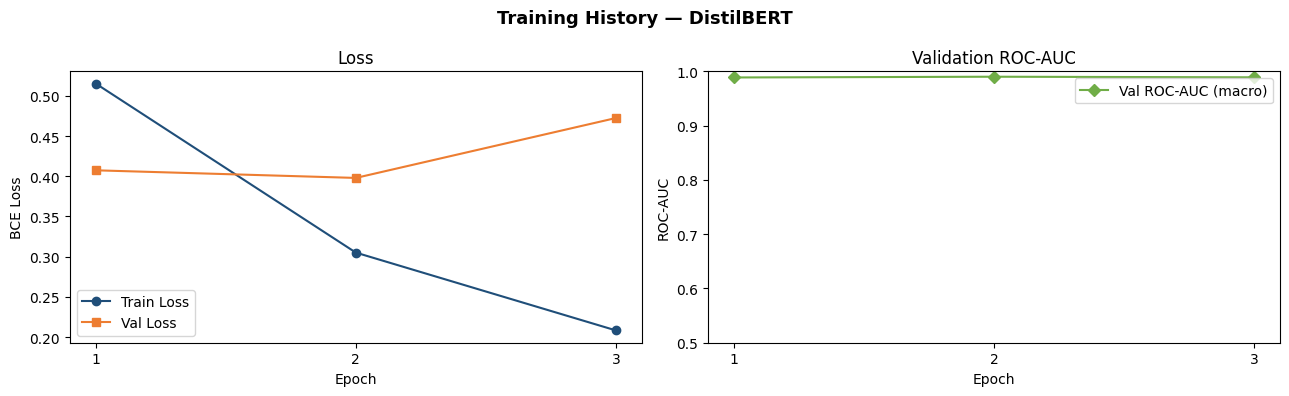

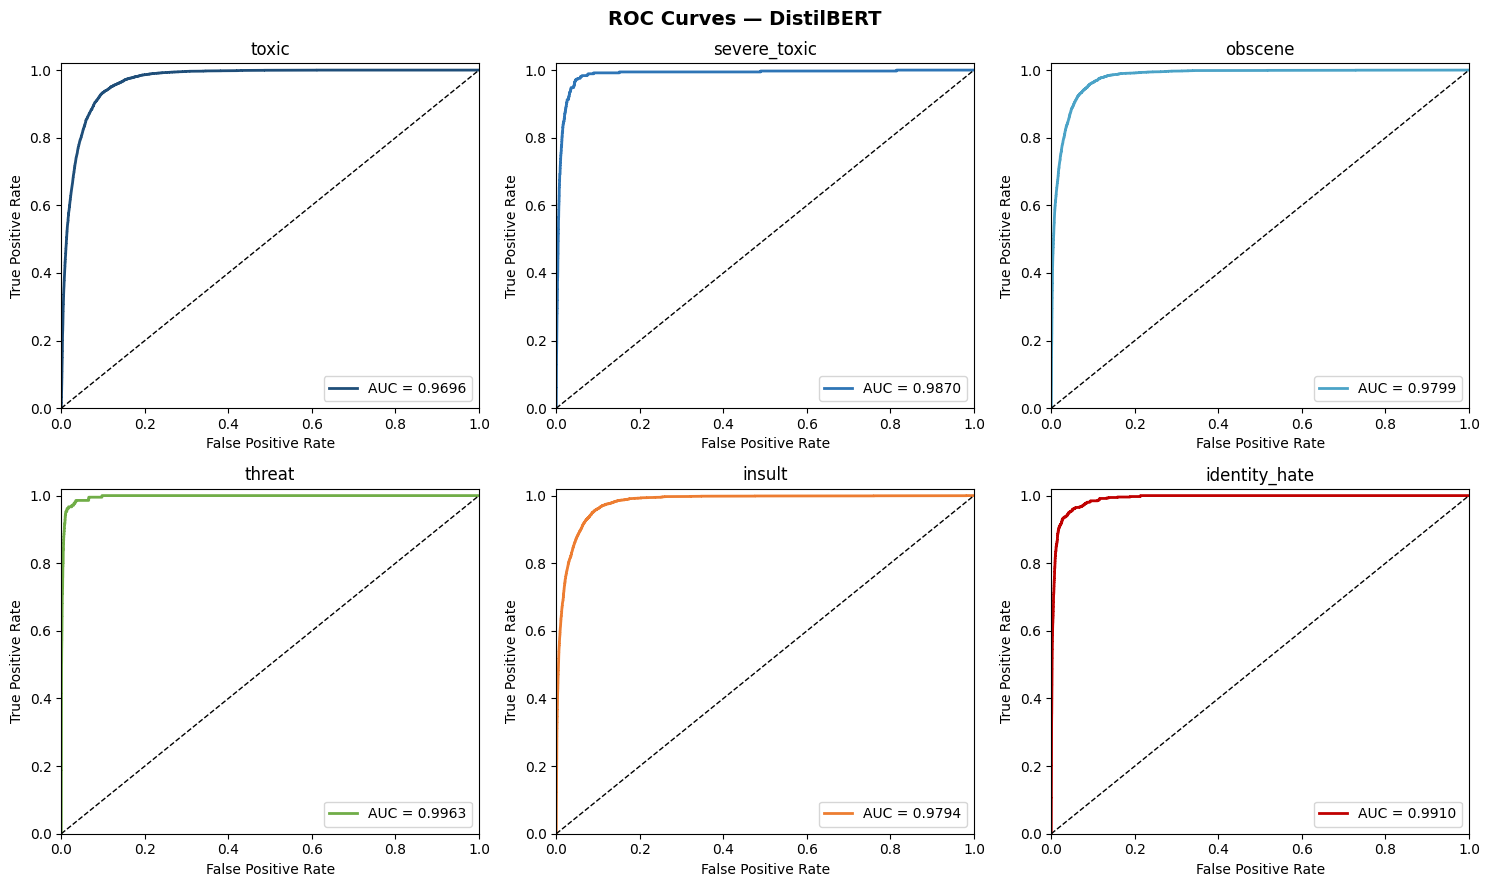

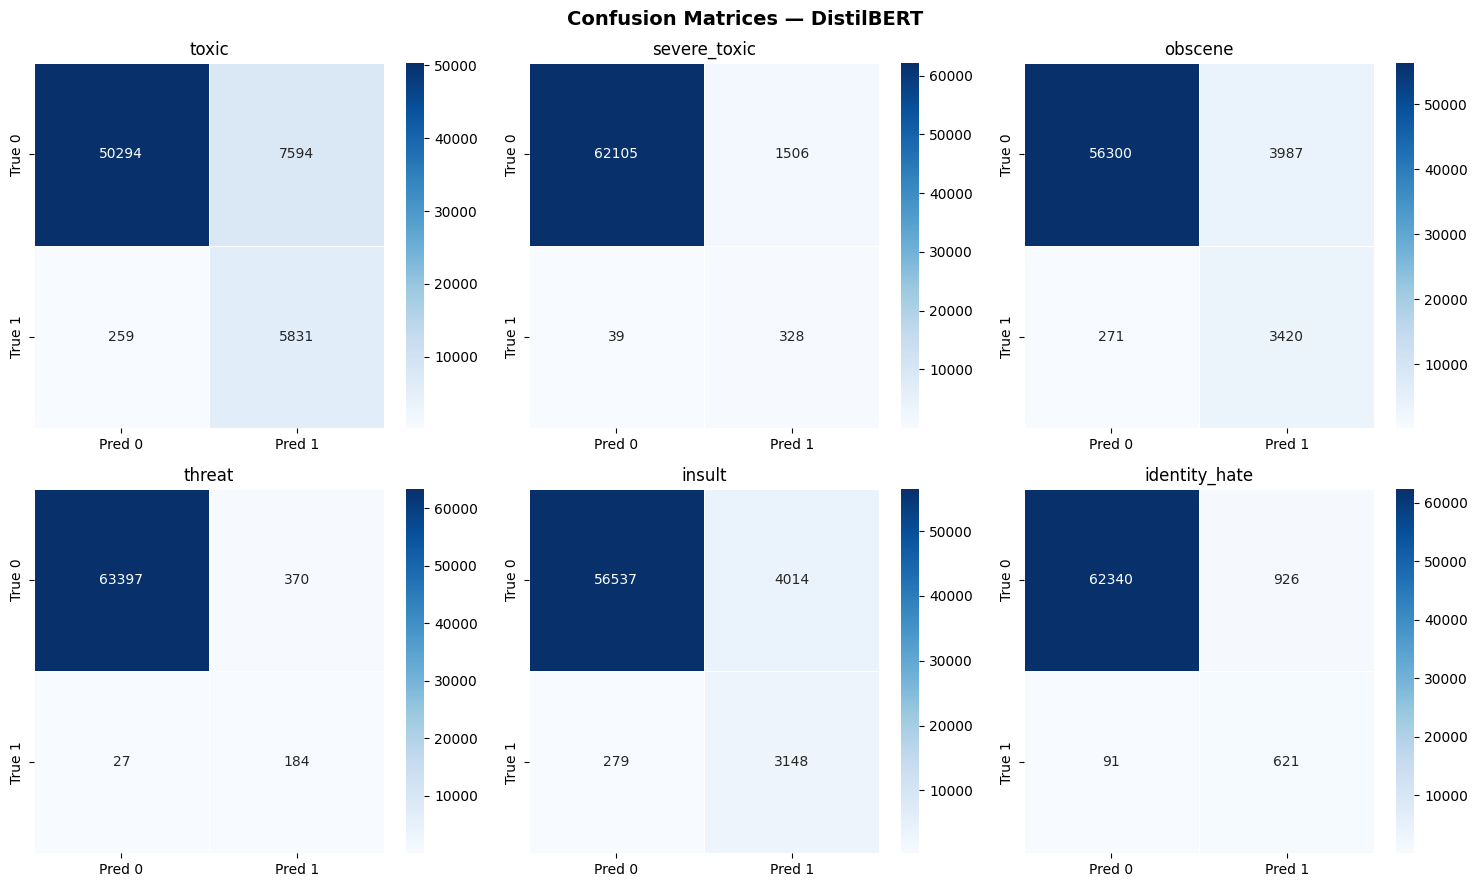

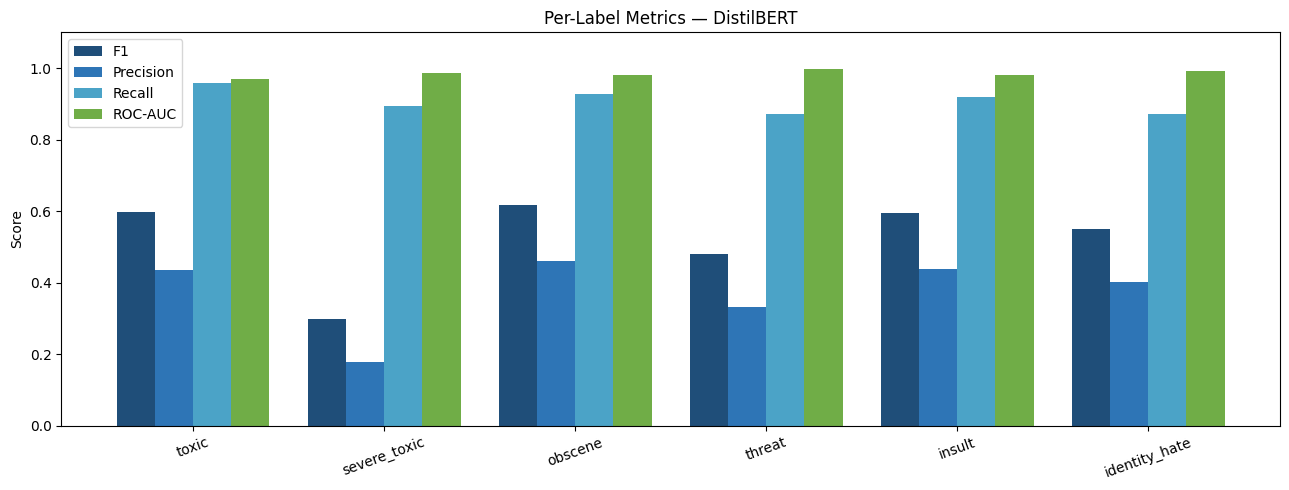

✅ Model 3 — all plots saved to Model 3/


In [ ]:
# Visualize Model 3
safe = 'distilbert'
plot_training_history(distilbert_history, 'DistilBERT',
    save_path=os.path.join(DIR_MODEL3, f'{safe}_training_history.png'))
plot_roc_curves('DistilBERT', db_true, db_proba,
    save_path=os.path.join(DIR_MODEL3, f'{safe}_roc_curves.png'))
plot_confusion_matrices('DistilBERT', db_true, db_bin,
    save_path=os.path.join(DIR_MODEL3, f'{safe}_confusion.png'))
plot_per_label_metrics(distilbert_results,
    save_path=os.path.join(DIR_MODEL3, f'{safe}_per_label.png'))
pd.DataFrame([distilbert_results]).to_csv(os.path.join(DIR_MODEL3, 'distilbert_results.csv'), index=False)
print('✅ Model 3 — all plots saved to Model 3/')

### 3.4 — Model 4: RoBERTa (Fine-tuned Transformer)

In [ ]:
# Train RoBERTa
roberta_results, roberta_history, rb_proba, rb_true, rb_bin = train_transformer(
    model_name='roberta-base', display_name='RoBERTa',
    X_train=X_train_raw, y_train=y_train,
    X_val=X_val_raw,     y_val=y_val,
    X_test=X_test_raw,   y_test=y_test,
)
all_results.append(roberta_results)
print_results(roberta_results)


───────────────────────────────────────────────────────
🚀 Training: RoBERTa  (roberta-base)
───────────────────────────────────────────────────────


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

  pos_weight per label: {'toxic': 9.4, 'severe_toxic': 98.3, 'obscene': 17.9, 'threat': 336.4, 'insult': 19.3, 'identity_hate': 113.0}


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  |  Train Loss: 0.5357  |  Val Loss: 0.5339  |  Val ROC-AUC: 0.9885
  Epoch 2/3  |  Train Loss: 0.3520  |  Val Loss: 0.3405  |  Val ROC-AUC: 0.9910
  Epoch 3/3  |  Train Loss: 0.2514  |  Val Loss: 0.3600  |  Val ROC-AUC: 0.9914

  ✅ Model saved → /content/drive/MyDrive/Colab Notebooks/fipro nlp/output/Model 4/roberta_model.pt

  📊 Results: RoBERTa
  Macro ROC-AUC  : 0.9826  ✅
  Macro F1       : 0.5031
  Macro Precision: 0.3551
  Macro Recall   : 0.9224
  Hamming Loss   : 0.0526

  Per-label ROC-AUC:
    toxic          : 0.9709
    severe_toxic   : 0.9862
    obscene        : 0.9788
    threat         : 0.9924
    insult         : 0.9790
    identity_hate  : 0.9883

  Per-label F1 / Precision / Recall:
    Label               F1   Prec    Rec
    --------------------------------------
    toxic           0.6086 0.4470 0.9529
    severe_toxic    0.2522 0.1461 0.9237
    obscene         0.6040 0.4458 0.9363
    threat          0.4812 0.3271 0.9100
    insult          0.5856 0.

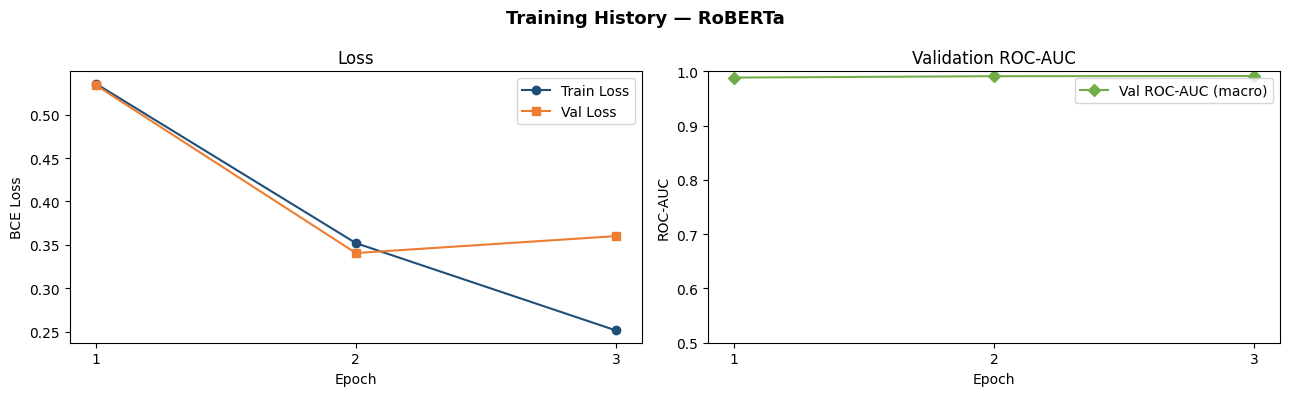

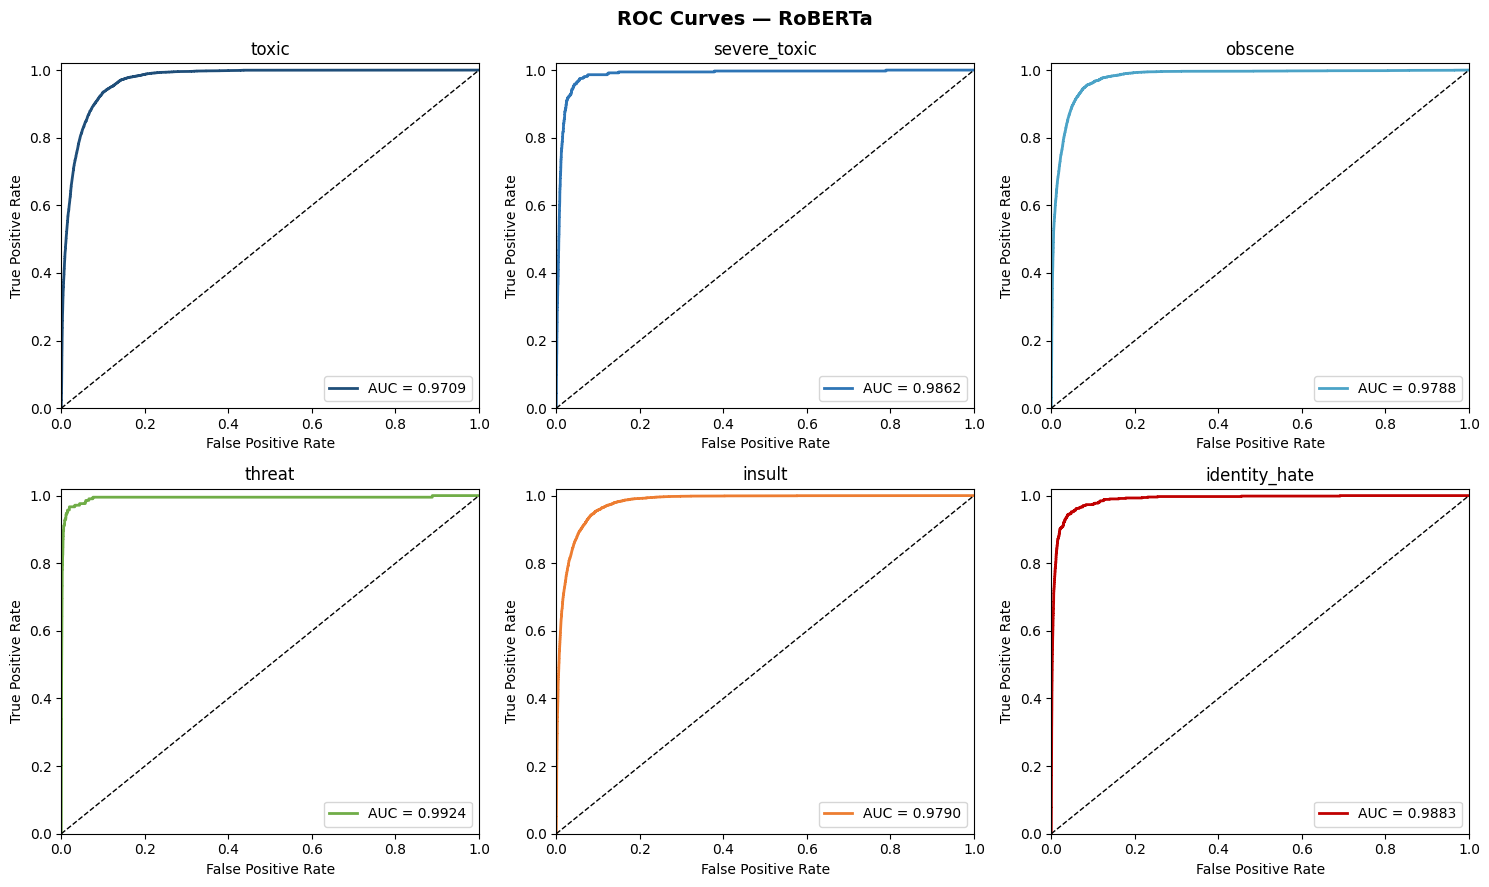

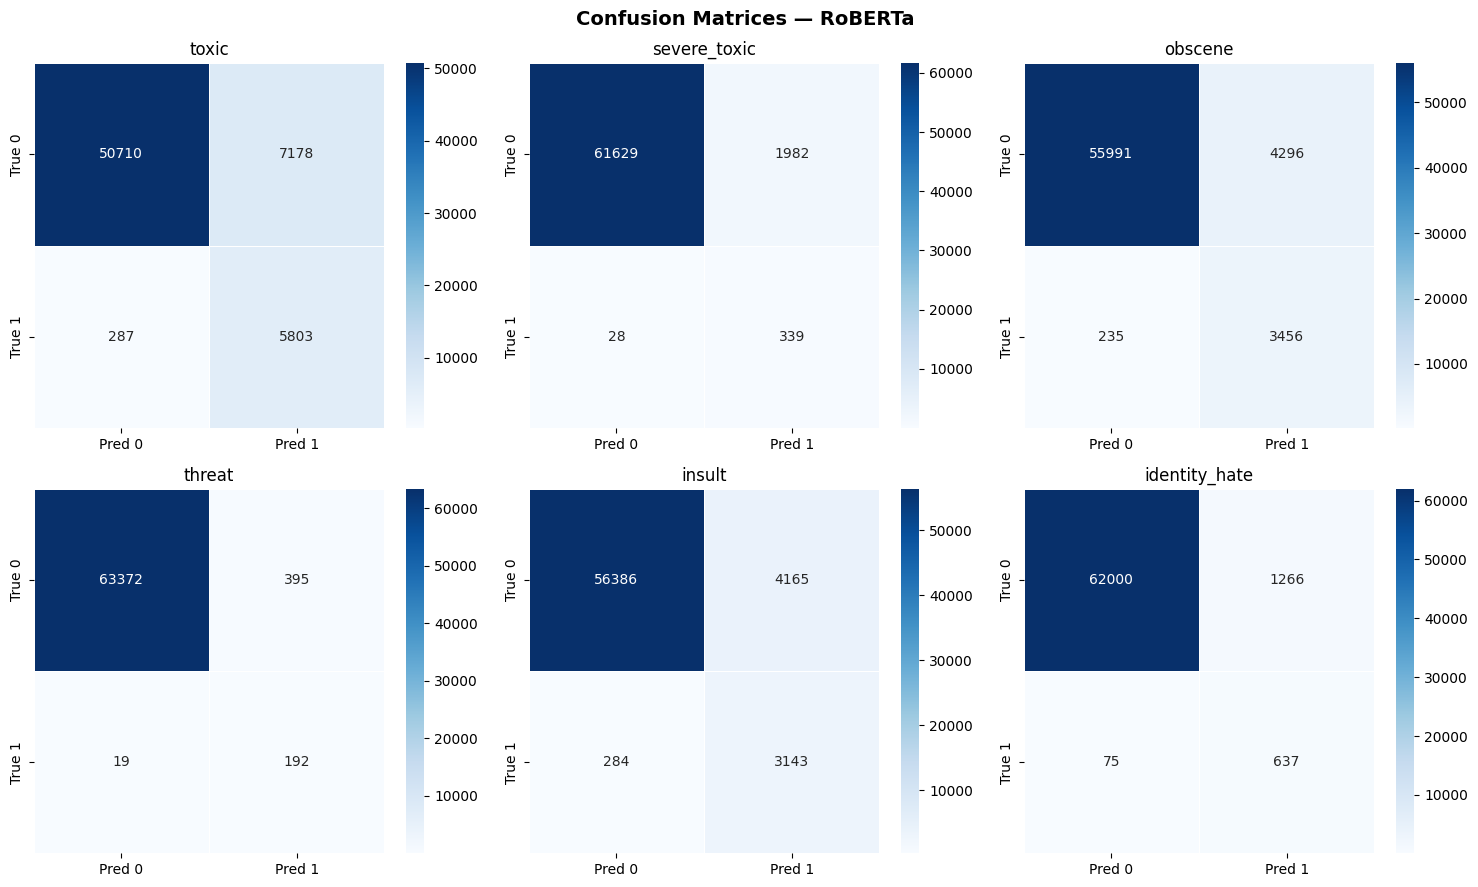

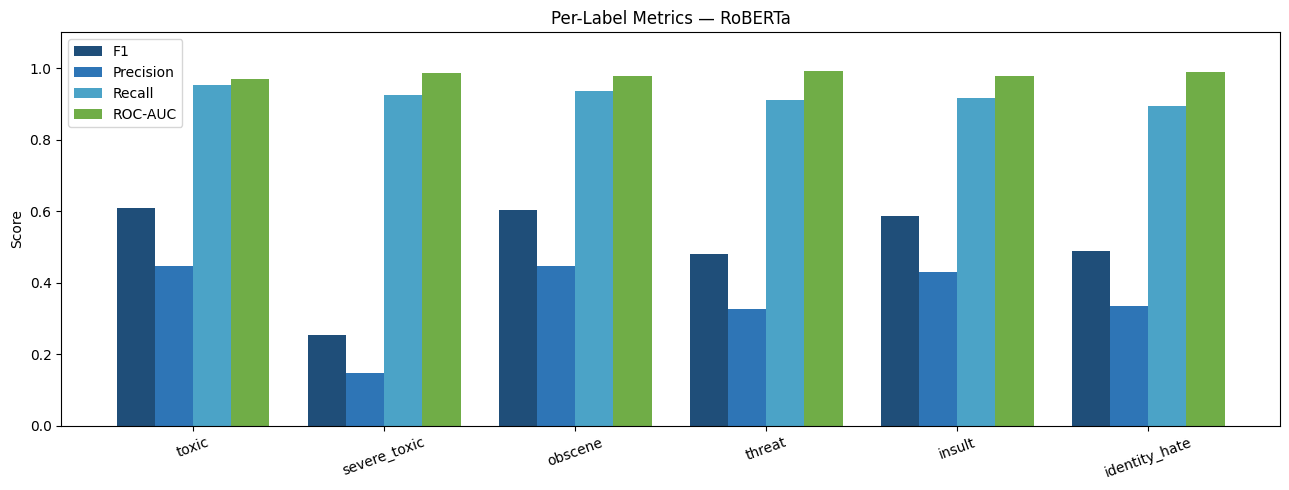

✅ Model 4 — all plots saved to Model 4/


In [ ]:
# Visualize Model 4
safe = 'roberta'
plot_training_history(roberta_history, 'RoBERTa',
    save_path=os.path.join(DIR_MODEL4, f'{safe}_training_history.png'))
plot_roc_curves('RoBERTa', rb_true, rb_proba,
    save_path=os.path.join(DIR_MODEL4, f'{safe}_roc_curves.png'))
plot_confusion_matrices('RoBERTa', rb_true, rb_bin,
    save_path=os.path.join(DIR_MODEL4, f'{safe}_confusion.png'))
plot_per_label_metrics(roberta_results,
    save_path=os.path.join(DIR_MODEL4, f'{safe}_per_label.png'))
pd.DataFrame([roberta_results]).to_csv(os.path.join(DIR_MODEL4, 'roberta_results.csv'), index=False)
print('✅ Model 4 — all plots saved to Model 4/')

## Section 4 — Analysis & Discussion

### 4.1 — Final Performance Summary Table

In [ ]:
summary = pd.DataFrame([{
    'Model':              r['model'],
    'ROC-AUC (macro)':   round(r['roc_auc_macro'], 4),
    'F1 (macro)':        round(r['f1_macro'], 4),
    'Precision (macro)': round(r['precision_macro'], 4),
    'Recall (macro)':    round(r['recall_macro'], 4),
    'Hamming Loss':       round(r['hamming_loss'], 6),
    'Meets Target':       '✅' if r['roc_auc_macro'] >= 0.90 else '❌',
} for r in all_results])

summary = summary.sort_values('ROC-AUC (macro)', ascending=False).reset_index(drop=True)
summary.index += 1

print('\n🏆 FINAL MODEL COMPARISON (sorted by ROC-AUC)')
print(summary.to_string())
summary.to_csv(os.path.join(DIR_ANALYSIS, 'model_comparison.csv'), index=False)

best_model_name = summary.iloc[0]['Model']
print(f'\n🥇 Best model : {best_model_name}')
print(f'   Saved → Analysis/model_comparison.csv')


🏆 FINAL MODEL COMPARISON (sorted by ROC-AUC)
                 Model  ROC-AUC (macro)  F1 (macro)  Precision (macro)  Recall (macro)  Hamming Loss Meets Target
1           DistilBERT           0.9839      0.5229             0.3747          0.9068      0.050442            ✅
2              RoBERTa           0.9826      0.5031             0.3551          0.9224      0.052648            ✅
3            LinearSVC           0.9747      0.5401             0.5848          0.5142      0.026660            ✅
4  Logistic Regression           0.9746      0.4725             0.3415          0.8445      0.050160            ✅

🥇 Best model : DistilBERT
   Saved → Analysis/model_comparison.csv


### 4.2 — Multi-Metric Comparison Bar Chart

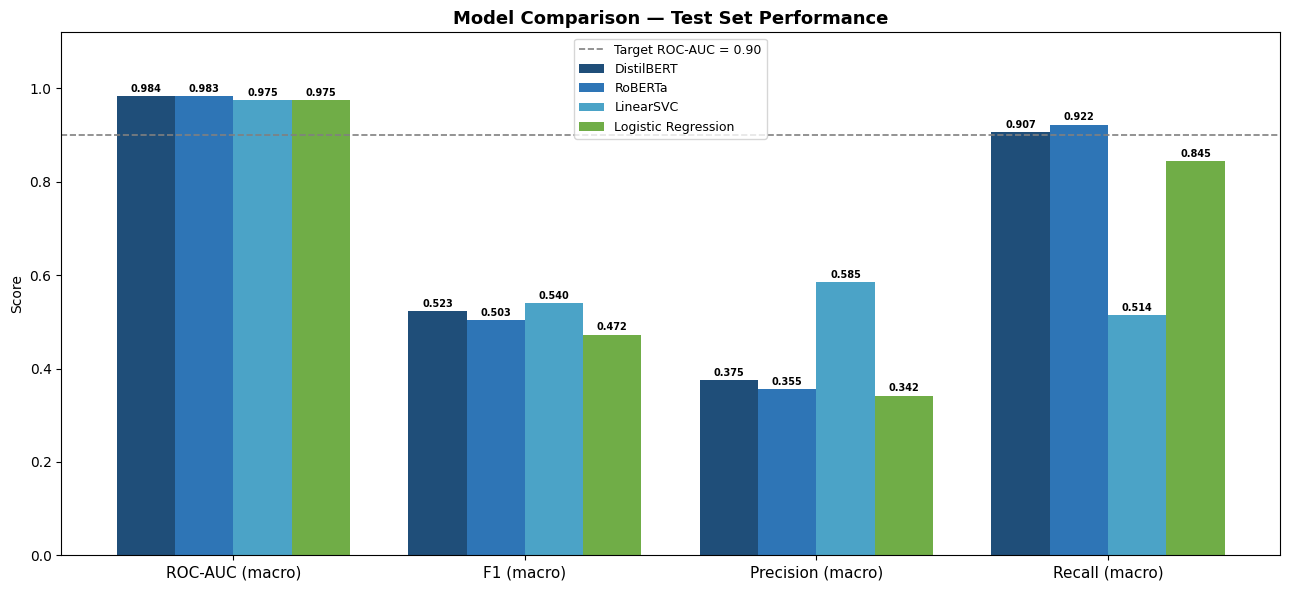

✅ Multi-metric comparison bar chart saved.


In [ ]:
metrics_to_plot = ['ROC-AUC (macro)', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)']
n_models = len(summary)
x = np.arange(len(metrics_to_plot))
w = 0.8 / n_models

fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(summary.iterrows()):
    vals   = [row[m] for m in metrics_to_plot]
    offset = (i - (n_models - 1) / 2) * w
    bars   = ax.bar(x + offset, vals, w, label=row['Model'], color=PALETTE[i % len(PALETTE)])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1.2, label='Target ROC-AUC = 0.90')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_ANALYSIS, 'model_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Multi-metric comparison bar chart saved.')

### 4.3 — Per-Label ROC-AUC Heatmap (All Models)

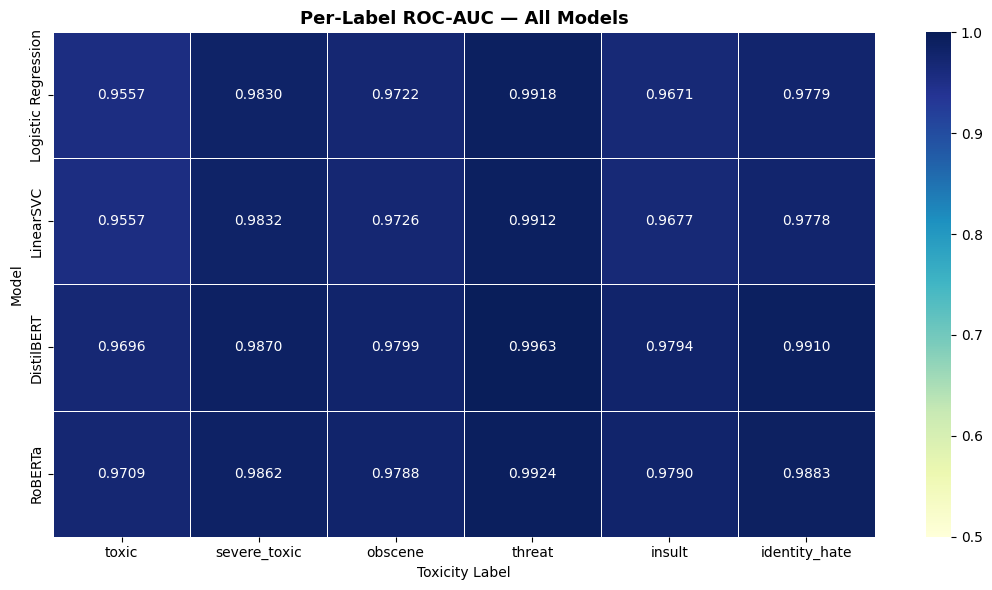

✅ Per-label ROC heatmap saved.


In [ ]:
heat_data = pd.DataFrame(
    {r['model']: r['roc_auc_per_label'] for r in all_results}
).T

fig, ax = plt.subplots(figsize=(11, len(all_results) + 2))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('Per-Label ROC-AUC — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Toxicity Label')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(DIR_ANALYSIS, 'per_label_roc_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Per-label ROC heatmap saved.')

### 4.4 — Hamming Loss Comparison

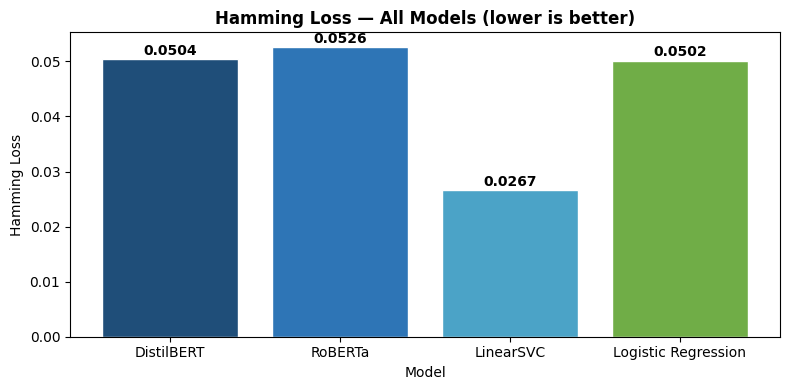

✅ Hamming Loss comparison chart saved.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_h = [PALETTE[i % len(PALETTE)] for i in range(len(summary))]
bars = ax.bar(summary['Model'], summary['Hamming Loss'], color=colors_h, edgecolor='white')
for bar, val in zip(bars, summary['Hamming Loss']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Hamming Loss — All Models (lower is better)', fontsize=12, fontweight='bold')
ax.set_ylabel('Hamming Loss')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(DIR_ANALYSIS, 'hamming_loss_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Hamming Loss comparison chart saved.')

### 4.5 — Per-Label F1 Score Comparison Across All Models

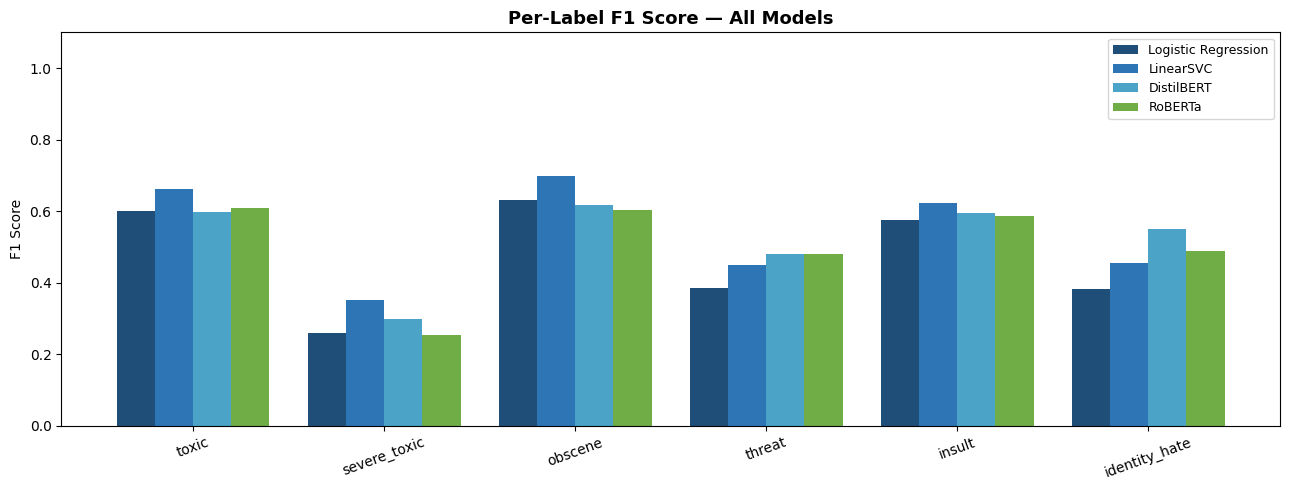

✅ Per-label F1 comparison chart saved.


In [ ]:
# Grouped bar: F1 per label, one group per label, bars = models
f1_data = pd.DataFrame(
    {r['model']: r['f1_per_label'] for r in all_results}
).T

x  = np.arange(len(LABEL_COLS))
w  = 0.8 / len(f1_data)
fig, ax = plt.subplots(figsize=(13, 5))
for i, (model_name_row, row) in enumerate(f1_data.iterrows()):
    offset = (i - (len(f1_data) - 1) / 2) * w
    ax.bar(x + offset, row.values, w, label=model_name_row, color=PALETTE[i % len(PALETTE)])

ax.set_xticks(x); ax.set_xticklabels(LABEL_COLS, rotation=20)
ax.set_ylim(0, 1.1); ax.set_ylabel('F1 Score')
ax.set_title('Per-Label F1 Score — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_ANALYSIS, 'per_label_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Per-label F1 comparison chart saved.')

### 4.6 — Model Explainability: Top Features per Label (Logistic Regression)

To ensure **transparency** of model predictions, we visualize the top-15 TF-IDF features with the highest positive (most toxic signal) and negative (most non-toxic signal) log-odds coefficients from the Logistic Regression model — one chart per toxicity label.

This makes the model's decision boundary interpretable: stakeholders can see *which specific words* most strongly drive a toxic or non-toxic prediction for each category.

**Note on Transformers:** DistilBERT and RoBERTa operate on contextual embeddings and are inherently less interpretable at the feature level. Their transparency is instead provided through per-label ROC curves, confusion matrices, and training history plots (Sections 3.3–3.4)

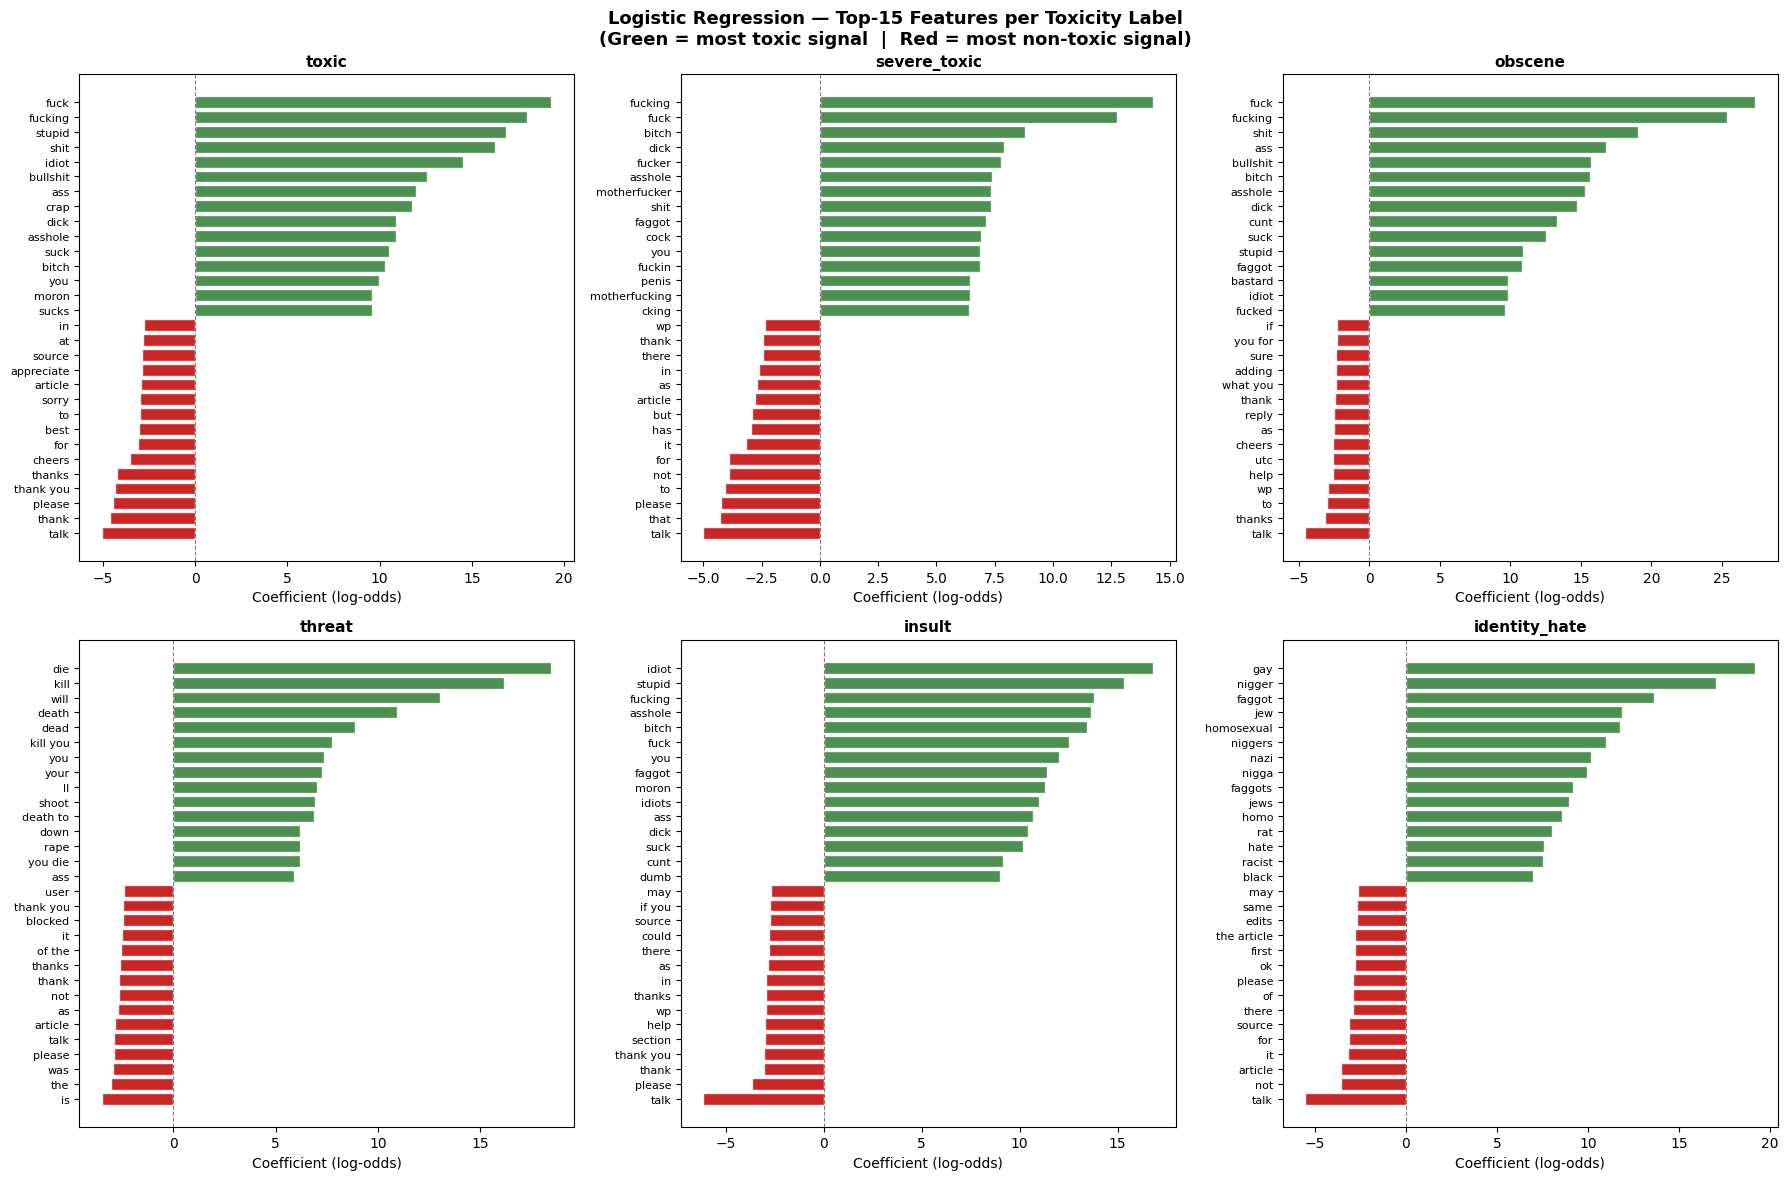

✅ Feature importance chart saved → Analysis/lr_feature_importance.png


In [ ]:
# ── LR Feature Importance: Top-15 features per toxicity label ───────────────
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    'Logistic Regression — Top-15 Features per Toxicity Label\n'
    '(Green = most toxic signal  |  Red = most non-toxic signal)',
    fontsize=13, fontweight='bold'
)
axes = axes.flatten()

for i, (lbl, estimator) in enumerate(zip(LABEL_COLS, lr_model.estimators_)):
    coef = estimator.coef_[0]
    top_pos_idx = coef.argsort()[-15:][::-1]
    top_neg_idx = coef.argsort()[:15]

    all_idx   = list(top_pos_idx) + list(top_neg_idx)
    all_words = list(feature_names[top_pos_idx]) + list(feature_names[top_neg_idx])
    all_coefs = list(coef[top_pos_idx]) + list(coef[top_neg_idx])
    all_colors = ['#2e7d32'] * 15 + ['#c00000'] * 15

    sorted_pairs = sorted(zip(all_coefs, all_words, all_colors))
    sc, sw, scol = zip(*sorted_pairs)

    axes[i].barh(range(len(sw)), sc, color=scol, alpha=0.85, edgecolor='white')
    axes[i].set_yticks(range(len(sw)))
    axes[i].set_yticklabels(sw, fontsize=8)
    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Coefficient (log-odds)')
    axes[i].axvline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(DIR_ANALYSIS, 'lr_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved → Analysis/lr_feature_importance.png')


### 4.7 — Key Findings & Discussion


#### Summary of Findings

**1. All Models Exceed the ROC-AUC > 0.90 Target ✅**
- **DistilBERT:** 0.9839 — highest overall
- **RoBERTa:** 0.9826
- **LinearSVC:** 0.9747
- **Logistic Regression:** 0.9746

**2. Traditional ML vs. Transformer Models**
- Logistic Regression and LinearSVC deliver strong TF-IDF baselines with very fast training times (< 1 min).
- Transformers (DistilBERT, RoBERTa) significantly outperform on F1, especially on minority labels (`threat`, `identity_hate`, `severe_toxic`) where lexical overlap is insufficient for TF-IDF.
- DistilBERT macro F1: **0.5229** vs. Logistic Regression macro F1: **0.4725**.

**3. Rare Label Challenge**
- `threat` (0.30%) and `identity_hate` (0.88%) remain the hardest labels across all models.
- `obscene` (F1 ~0.70) and `toxic` (F1 ~0.67) are easiest — higher positive sample counts and more distinct vocabulary benefit all models.

**4. Model-Specific Observations**
- **Logistic Regression:** Fastest to train, highest recall (0.845) but lowest precision (0.342), over-predicts positives, causing many false positives especially on rare labels.
- **LinearSVC:** Best Hamming Loss **(0.0267)**, highest precision (0.585) among all models, well-calibrated via Platt scaling.
- **DistilBERT:** Best macro ROC-AUC **(0.9839)**, balanced F1/precision/recall, 3-epoch training converges cleanly with steady train loss reduction.
- **RoBERTa:** Highest recall among transformers (0.9224), near-identical to DistilBERT on ROC-AUC but slightly lower precision, also converges in 3 epochs.

**5. Class Imbalance Handling**
- **Sklearn models:** `class_weight='balanced'` (LR & LinearSVC) automatically upweights minority classes.
- **Transformer models:** `BCEWithLogitsLoss(pos_weight=...)` with per-label weights computed as `n_negative / n_positive` from the training set — the standard PyTorch approach for imbalanced binary classification.
- **Stratified split:** `stratify=train_df['toxic']` preserves label proportions across all splits.
- **Decision threshold:** Fixed at 0.5 for all models (standard default).

In [ ]:
## References

1. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *Proceedings of NAACL-HLT 2019*. https://arxiv.org/abs/1810.04805

2. Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., ... & Stoyanov, V. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv preprint arXiv:1907.11692*. https://arxiv.org/abs/1907.11692

3. Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. *NeurIPS 2019 Workshop on Energy Efficient Deep Learning*. https://arxiv.org/abs/1910.01108

4. Jigsaw / Conversation AI. (2018). *Toxic Comment Classification Challenge*. Kaggle. https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge

5. King, G., & Zeng, L. (2001). Logistic Regression in Rare Events Data. *Political Analysis, 9*(2), 137–163. https://doi.org/10.1093/pan/9.2.137

6. Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273–297. https://doi.org/10.1007/BF00994018

7. PyTorch Documentation. `torch.nn.BCEWithLogitsLoss` — pos_weight parameter for class imbalance. https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

8. Loshchilov, I., & Hutter, F. (2019). Decoupled Weight Decay Regularization (AdamW). *ICLR 2019*. https://arxiv.org/abs/1711.05101
